In [1]:
"""
【示例1】Tushare获取数据。
"""
# 第一步：导入tushare模块
import tushare as ts

# 第二步：设置tushare Pro版本的token
ts.set_token('7c0a9136f16b24498a63ba46c9cd534bc9428f6d4c9d1f711294c911')

# 第三步：初始化pro接口
pro = ts.pro_api()

# 第四步：数据调取（以获取交易日历信息为例）
df = pro.daily(ts_code='000001.SZ', start_date='20230101', end_date='20230330')

# 打印前2行数据
print(df.head(2))


     ts_code trade_date   open   high    low  close  pre_close  change  \
0  000001.SZ   20230330  12.55  12.71  12.41  12.68      12.53    0.15   
1  000001.SZ   20230329  12.73  12.74  12.50  12.53      12.64   -0.11   

   pct_chg        vol       amount  
0   1.1971  824546.24  1035422.932  
1  -0.8703  596064.33   750687.551  


In [2]:
"""
【示例2】Tushare获取股票列表（沪深股市基本信息）.
"""
# 导入所需库
import tushare as ts
import pandas as pd

# 设置Tushare Token（需提前注册获取，官网：https://tushare.pro）
ts.set_token('7c0a9136f16b24498a63ba46c9cd534bc9428f6d4c9d1f711294c911')  # 替换为你的实际token
pro = ts.pro_api()

# 调用stock_basic接口获取股票基本信息
stock_list = pro.stock_basic(
    exchange='',  # 交易所（空字符串表示全部）
    list_status='L',  # 上市状态：L上市，D退市
    fields='ts_code,symbol,name,area,industry,list_date'
)

# 解释字段含义
# ts_code: 股票代码（后缀.SH表示沪市，.SZ表示深市）
# symbol: 股票数字代码（仅数字部分）
# name: 股票名称
# industry: 所属行业
# list_date: 上市日期（YYYYMMDD格式）

# 保存为CSV文件（注意路径需存在）
stock_list.to_csv('./stock_list.csv', index=False, encoding='utf-8-sig')
print("股票列表已保存为stock_list.csv")

股票列表已保存为stock_list.csv


In [8]:
"""
【示例3】Tushare获取茅台股票的信息.
"""
import tushare as ts
import pandas as pd
from datetime import datetime, timedelta

# 设置时间范围：获取过去一年的数据
end_date = datetime.now().strftime('%Y%m%d')
start_date = (datetime.now() - timedelta(days=365)).strftime('%Y%m%d')

# 调用daily接口获取日线数据
df_daily = ts.pro_bar(
    ts_code='600519.SH',  # 贵州茅台股票代码
    asset='E',            # E表示股票
    start_date=start_date,
    end_date=end_date,
    adj='qfq'             # 复权方式：qfq前复权
)

# 解释关键字段
# trade_date: 交易日期
# open: 开盘价, high: 最高价, low: 最低价, close: 收盘价
# vol: 成交量（单位：手），amount: 成交额（单位：千元）

# 按日期排序
df_daily = df_daily.sort_values('trade_date')

# 对比接口说明：
# 1. ts.pro_bar() 是通用接口，可获取股票、基金、期货等数据
# 2. ts.daily() 是旧版股票日线接口（推荐使用pro_bar）

print("贵州茅台最近5个交易日数据：")
print(df_daily[['trade_date', 'open', 'close', 'vol']].head())

# 保存到Excel
df_daily.to_excel('./600519_daily.xlsx', index=False)

贵州茅台最近5个交易日数据：
    trade_date     open    close       vol
241   20240410  1603.54  1589.75  27630.50
240   20240411  1582.16  1589.77  22766.24
239   20240412  1592.67  1576.30  26744.33
238   20240415  1577.24  1613.87  35817.71
237   20240416  1606.64  1610.99  26266.23


D:\anaconda3\Lib\site-packages\tushare\pro\data_pro.py:130: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['adj_factor'] = data['adj_factor'].fillna(method='bfill')


In [40]:
"""
【示例4】Tushare批量获取多支股票数据（银行、科技、消费行业）
"""

import tushare as ts
import pandas as pd
import time

    # 暂停控制频率（每秒调用1次）


# 股票代码列表（示例：平安银行、中兴通讯、伊利股份）
stock_codes = ['000001.SZ', '000063.SZ', '600887.SH']

# 初始化DataFrame存放所有数据
all_data = pd.DataFrame()

# 循环获取数据（注意频率限制！）
for code in stock_codes:
    # 调用接口（限制：免费版每分钟最多调用50次）
    df = ts.pro_bar(
        ts_code=code,
        asset='E',
        start_date='20230101',
        end_date='20231231'
    )
    
    # 添加股票代码列以便区分
    df['stock_code'] = code
    
    # 合并数据
    all_data = pd.concat([all_data, df], ignore_index=True)
    
    # 暂停控制频率（每秒调用1次）
    time.sleep(1)  

# 查看结果
print("获取到的总数据量：", len(all_data))
print("前3行数据示例：")
print(all_data[['stock_code', 'trade_date', 'close']].head(3))

# 保存到Excel
all_data.to_excel('./3stocks_daily.xlsx', index=False)

获取到的总数据量： 726
前3行数据示例：
  stock_code trade_date  close
0  000001.SZ   20231229   9.39
1  000001.SZ   20231228   9.45
2  000001.SZ   20231227   9.12


In [42]:
"""
【示例4】Tushare批量获取多支股票数据（银行、科技、消费行业）
构建简单投资组合
"""

def build_simple_portfolio(stock_list, start_date='20230101', end_date='20231231'):
    """
    构建简单投资组合并分析
    
    参数:
    stock_list: list - 股票代码列表，格式为['000001.SZ', '600036.SH']等
    start_date: str - 开始日期，格式为'YYYYMMDD'，默认'20230101'
    end_date: str - 结束日期，格式为'YYYYMMDD'，默认'20231231'
    
    返回:
    portfolio_data: dict - 包含各股票原始数据的字典
    returns_df: DataFrame - 包含各股票日收益率的DataFrame
    """
    print("\n=== 构建投资组合分析 ===")
    
    # 初始化一个空字典来存储投资组合中每只股票的数据
    # 键：股票代码，值：对应的日线数据DataFrame
    portfolio_data = {}
    
    # 遍历股票列表，获取每只股票的历史数据
    for stock in stock_list:
        # 使用tushare pro接口获取日线行情数据
        df = pro.daily(
            ts_code=stock,
            start_date=start_date,
            end_date=end_date
        )
        
        # 检查是否成功获取到数据（DataFrame不为空）
        if len(df) > 0:
            # 将获取到的数据存储到字典中，以股票代码作为键
            portfolio_data[stock] = df
            print(f"成功获取 {stock} 的数据，共 {len(df)} 条记录")
        else:
            print(f"警告：未获取到 {stock} 的数据")
    
    # 初始化一个空字典来存储各股票的收益率数据
    returns_data = {}
    
    # 遍历投资组合中的每只股票数据，计算日收益率
    for stock, data in portfolio_data.items():
        # 按交易日期排序，确保数据按时间顺序排列
        # 这是重要的数据预处理步骤，因为原始数据可能不是按时间排序的
        data = data.sort_values('trade_date')
        
        # 计算日收益率：使用pct_change()函数计算收盘价的百分比变化
        # 公式：(今日收盘价 - 昨日收盘价) / 昨日收盘价
        data['return'] = data['close'].pct_change()
        
        # 将收益率数据存储到新字典中，并删除NaN值（第一行没有前一日数据，所以是NaN）
        # dropna()移除缺失值，确保数据质量
        returns_data[stock] = data['return'].dropna()
        
        print(f"{stock} 收益率计算完成，有效数据点：{len(returns_data[stock])}个")
    
    # 将收益率字典转换为DataFrame，便于后续分析
    # 每列代表一只股票的收益率序列，行代表不同的交易日
    returns_df = pd.DataFrame(returns_data)
    
    # 打印投资组合收益率的描述性统计信息
    print("\n投资组合收益率统计：")
    print(returns_df.describe())
    
    # 计算投资组合中股票收益率的相关性矩阵
    # corr()计算皮尔逊相关系数，衡量股票间的线性相关程度
    # 相关系数范围：-1到1
    # 1: 完全正相关，-1: 完全负相关，0: 无线性相关
    correlation_matrix = returns_df.corr()
    
    # 打印相关性矩阵
    # - 低相关性有助于降低组合风险
    # - 高相关性意味着股票同涨同跌，分散化效果差
    print("\n股票收益率相关性矩阵：")
    print(correlation_matrix)
    
    # 返回原始数据和收益率数据
    # portfolio_data: 可用于进一步的技术分析或其他计算
    # returns_df: 可直接用于风险分析、组合优化等
    return portfolio_data, returns_df

# 使用示例：构建一个包含三只股票的投资组合
# 股票代码说明：
# '000001.SZ' - 平安银行，深交所
# '600036.SH' - 招商银行，上交所  
# '601318.SH' - 中国平安，上交所
portfolio_stocks = ['000001.SZ', '600036.SH', '601318.SH']

# 调用函数构建投资组合并获取分析结果
# portfolio_data: 包含三只股票原始日线数据的字典
# returns_df: 包含三只股票日收益率的DataFrame
portfolio_data, returns_df = build_simple_portfolio(portfolio_stocks)


=== 构建投资组合分析 ===
投资组合收益率统计：
        000001.SZ   600036.SH   601318.SH
count  241.000000  241.000000  241.000000
mean    -0.001499   -0.001145   -0.000508
std      0.013378    0.014369    0.017062
min     -0.032000   -0.040663   -0.042017
25%     -0.010554   -0.010999   -0.009777
50%     -0.001781   -0.001527   -0.001444
75%      0.005141    0.006686    0.007071
max      0.053611    0.057870    0.100022

股票收益率相关性矩阵：
           000001.SZ  600036.SH  601318.SH
000001.SZ   1.000000   0.804986   0.770180
600036.SH   0.804986   1.000000   0.617021
601318.SH   0.770180   0.617021   1.000000


In [4]:
"""
Tushare获取股票指数数据
注意，上证指数的代码为000001；深证成指代码为399001.SZ；其他的指数均有对应的代码。
"""

import tushare as ts
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# 设置Tushare Token（需提前注册获取，官网：https://tushare.pro）
token = "7c0a9136f16b24498a63ba46c9cd534bc9428f6d4c9d1f711294c911"

# 初始化tushare
ts.set_token(token)
pro = ts.pro_api()

print("Tushare初始化成功！")


def get_index_data(index_code='000001.SH', start_date='20230101', end_date='20231231'):
    """
    获取指数数据
    """
    print(f"\n=== 获取指数 {index_code} 数据 ===")
    
    try:
        # 获取指数日线数据
        df = pro.index_daily(
            ts_code=index_code,
            start_date=start_date,
            end_date=end_date
        )
        
        if len(df) > 0:
            print(f"成功获取 {len(df)} 条指数数据")
            print(f"数据时间范围：{df['trade_date'].min()} 到 {df['trade_date'].max()}")
            
            # 显示数据
            print("\n指数数据示例：")
            print(df[['trade_date', 'open', 'high', 'low', 'close', 'vol']].head())
            
            return df
        else:
            print("未获取到数据")
            return None
            
    except Exception as e:
        print(f"获取指数数据时出错：{e}")
        return None

# 获取上证指数数据
sh_index_data = get_index_data('000001.SH')
# 保存到Excel
sh_index_data.to_excel('./SH000001.xlsx', index=False)

Tushare初始化成功！

=== 获取指数 000001.SH 数据 ===
成功获取 242 条指数数据
数据时间范围：20230103 到 20231229

指数数据示例：
  trade_date       open       high        low      close          vol
0   20231229  2950.8372  2975.0319  2950.0173  2974.9348  290672687.0
1   20231228  2913.1096  2961.6476  2909.3886  2954.7035  339213116.0
2   20231227  2900.1491  2917.9564  2890.1650  2914.6138  247900882.0
3   20231226  2917.9708  2917.9708  2892.8373  2898.8787  228140855.0
4   20231225  2909.8751  2920.6323  2903.9870  2918.8126  229814178.0


In [18]:
"""
Tushare获取大宗商品数据示例
注意，上证指数的代码为000001；深证成指代码为399001.SZ；其他的指数均有对应的代码。
"""

def get_futures_data(futures_code='CU1811.SHF', start_date='20180101', end_date='20231231'):
    """
    获取期货数据（大宗商品）
    futures_code: 期货代码，如AU0(黄金), AG0(白银), CU0(铜)等
    """
    print(f"\n=== 获取期货 {futures_code} 数据 ===")
    
    try:
        # 获取期货日线数据
        df = pro.fut_daily(
            ts_code=futures_code,
            start_date=start_date,
            end_date=end_date
        )
        
        if len(df) > 0:
            print(f"成功获取 {len(df)} 条期货数据")
            print(f"数据时间范围：{df['trade_date'].min()} 到 {df['trade_date'].max()}")
            
            # 显示数据
            print("\n期货数据示例：")
            print(df[['trade_date', 'open', 'high', 'low', 'close', 'vol', 'oi']].head())
            
            return df
        else:
            print("未获取到数据")
            return None
            
    except Exception as e:
        print(f"获取期货数据时出错：{e}")
        return None

# 获取黄金期货数据
futures_data = get_futures_data('CU1811.SHF')



#获取2018年11月13日大商所全部合约行情数据
df_all = pro.fut_daily(trade_date='20181113', exchange='DCE', fields='ts_code,trade_date,pre_close,pre_settle,open,high,low,close,settle,vol')

# 显示数据
print("\n期货数据示例2：")
print(df_all.head())




=== 获取期货 CU1811.SHF 数据 ===
成功获取 212 条期货数据
数据时间范围：20180102 到 20181115

期货数据示例：
  trade_date     open     high      low    close      vol       oi
0   20181115  48840.0  49350.0  48470.0  49300.0   3800.0   7210.0
1   20181114  49070.0  49240.0  48720.0  48750.0  14500.0   8850.0
2   20181113  48910.0  49040.0  48700.0  49030.0  17270.0  16110.0
3   20181112  49130.0  49200.0  48860.0  48900.0  27710.0  22940.0
4   20181109  49340.0  49530.0  49120.0  49270.0  22530.0  30100.0

期货数据示例2：
     ts_code trade_date  pre_close  pre_settle    open    high     low  \
0      A.DCE   20181113     3504.0      3493.0  3502.0  3509.0  3452.0   
1  A1811.DCE   20181113     3460.0      3448.0     NaN     NaN     NaN   
2  A1901.DCE   20181113     3504.0      3493.0  3502.0  3509.0  3452.0   
3  A1903.DCE   20181113     3498.0      3498.0  3578.0  3579.0  3529.0   
4  A1905.DCE   20181113     3715.0      3701.0  3718.0  3732.0  3680.0   

    close  settle       vol  
0  3471.0  3476.0  121434.0  
1  3

Tushare初始化成功！
=== 获取股票 002149.SZ 资金流向数据 ===
成功获取 242 条资金流向数据
数据时间范围: 20240102 到 20241231

资金流向数据前5行:
     ts_code trade_date  buy_sm_vol  buy_sm_amount  sell_sm_vol  \
0  002149.SZ   20240102       90063       14898.20        86267   
1  002149.SZ   20240103       49767        8238.72        48291   
2  002149.SZ   20240104       37617        6154.73        27638   
3  002149.SZ   20240105       46727        7486.29        42170   
4  002149.SZ   20240108       44443        6925.68        29885   

   sell_sm_amount  buy_md_vol  buy_md_amount  sell_md_vol  sell_md_amount  \
0        14233.14       83483       13787.68        78832        13023.32   
1         7999.78       36673        6084.32        46373         7687.06   
2         4527.42       21396        3502.96        28089         4593.79   
3         6756.85       20844        3339.96        21802         3492.07   
4         4673.16       21208        3303.85        33177         5160.62   

   buy_lg_vol  buy_lg_amount  sel

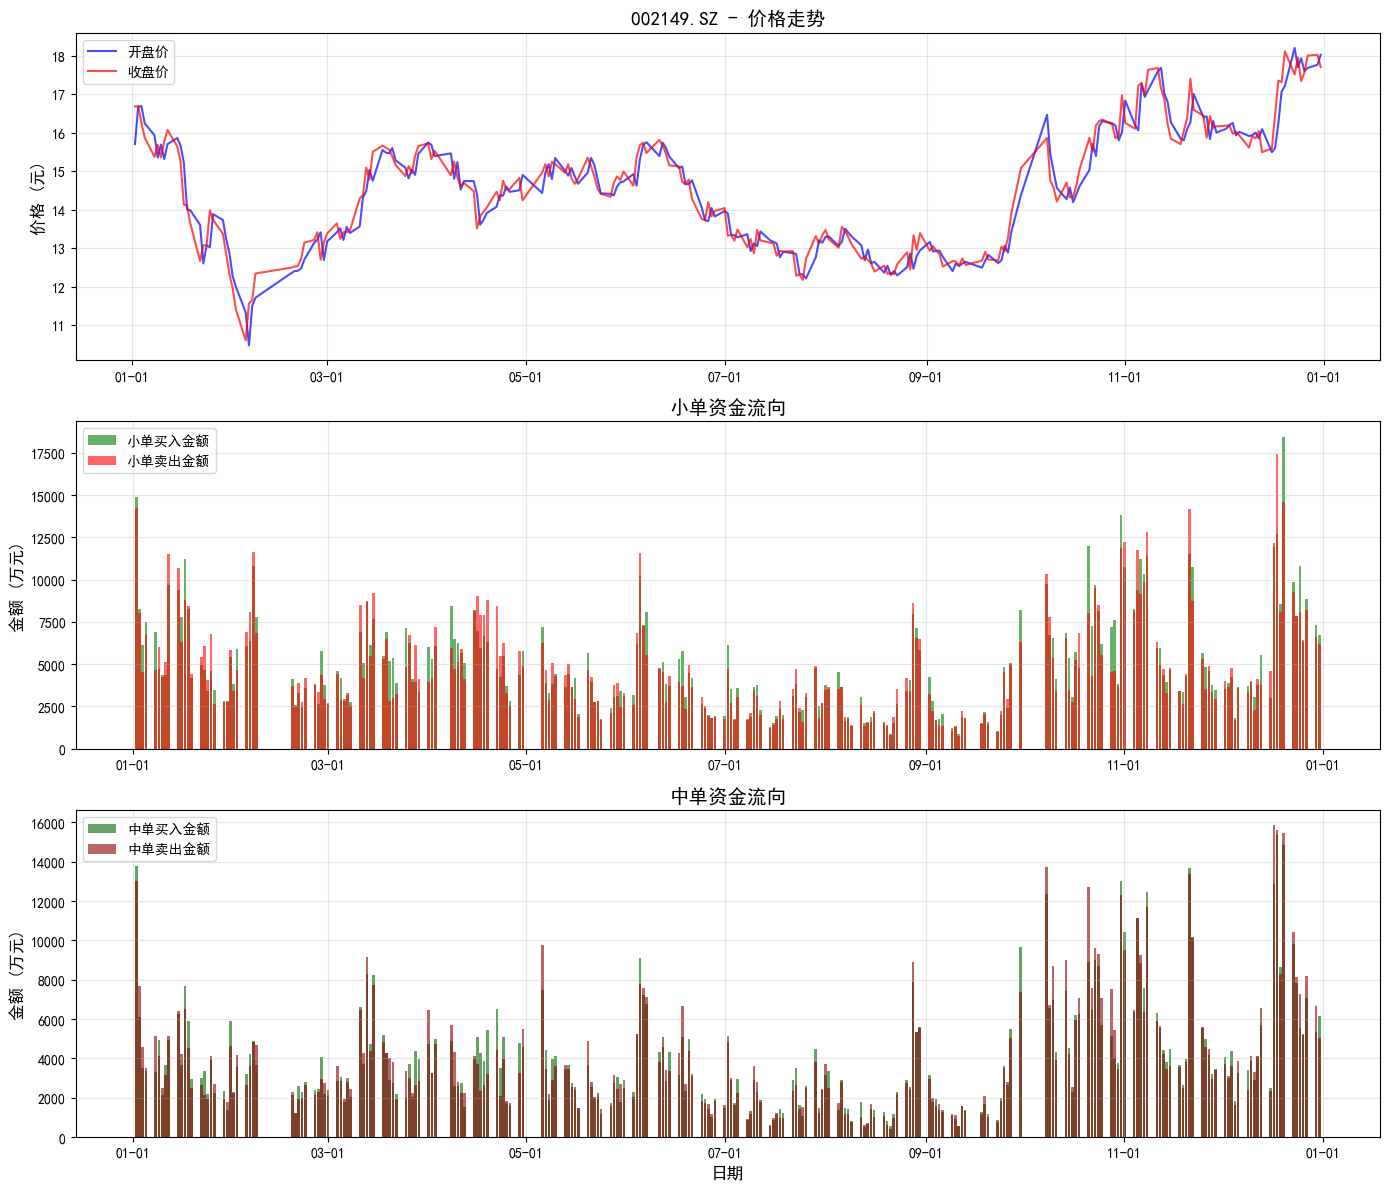

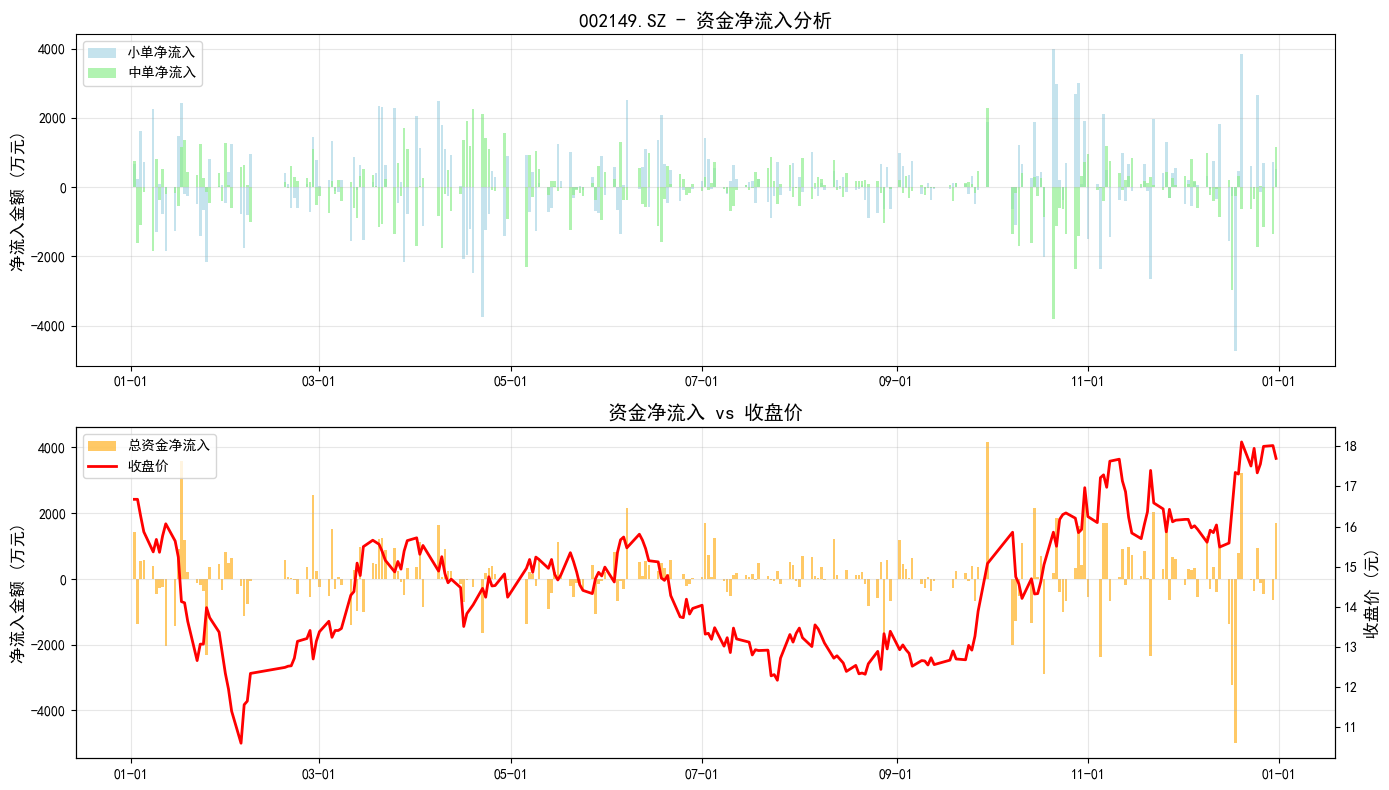


数据已保存到 002149.SZ_资金流向分析.csv


In [44]:
import tushare as ts
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# 设置Tushare Token（需提前注册获取，官网：https://tushare.pro）
token = "7c0a9136f16b24498a63ba46c9cd534bc9428f6d4c9d1f711294c911"

# 初始化tushare
ts.set_token(token)
pro = ts.pro_api()

print("Tushare初始化成功！")

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 用来正常显示中文标签
plt.rcParams['axes.unicode_minus'] = False    # 用来正常显示负号

def get_stock_moneyflow(ts_code, start_date, end_date):
    """
    获取单只股票的资金流向数据
    
    参数:
    ts_code: str - 股票代码，如'002149.SZ'
    start_date: str - 开始日期，格式'YYYYMMDD'
    end_date: str - 结束日期，格式'YYYYMMDD'
    
    返回:
    moneyflow_df: DataFrame - 资金流向数据
    """
    print(f"=== 获取股票 {ts_code} 资金流向数据 ===")
    
    try:
        # 使用moneyflow接口获取资金流向数据
        # ts_code: 股票代码
        # start_date: 开始日期
        # end_date: 结束日期
        moneyflow_df = pro.moneyflow(
            ts_code=ts_code,
            start_date=start_date,
            end_date=end_date
        )
        
        if moneyflow_df is not None and len(moneyflow_df) > 0:
            print(f"成功获取 {len(moneyflow_df)} 条资金流向数据")
            
            # 按交易日期排序
            moneyflow_df = moneyflow_df.sort_values('trade_date')
            
            # 重置索引
            moneyflow_df = moneyflow_df.reset_index(drop=True)
            
            # 显示数据基本信息
            print(f"数据时间范围: {moneyflow_df['trade_date'].iloc[0]} 到 {moneyflow_df['trade_date'].iloc[-1]}")
            print("\n资金流向数据前5行:")
            print(moneyflow_df.head())
            
            return moneyflow_df
        else:
            print("未获取到资金流向数据")
            return None
            
    except Exception as e:
        print(f"获取资金流向数据时出错: {e}")
        return None

def get_stock_daily_data(ts_code, start_date, end_date):
    """
    获取股票的日线行情数据
    
    参数:
    ts_code: str - 股票代码
    start_date: str - 开始日期
    end_date: str - 结束日期
    
    返回:
    daily_df: DataFrame - 日线行情数据
    """
    print(f"\n=== 获取股票 {ts_code} 日线行情数据 ===")
    
    try:
        # 使用daily接口获取日线数据
        daily_df = pro.daily(
            ts_code=ts_code,
            start_date=start_date,
            end_date=end_date
        )
        
        if daily_df is not None and len(daily_df) > 0:
            print(f"成功获取 {len(daily_df)} 条日线数据")
            
            # 按交易日期排序
            daily_df = daily_df.sort_values('trade_date')
            
            # 重置索引
            daily_df = daily_df.reset_index(drop=True)
            
            return daily_df
        else:
            print("未获取到日线数据")
            return None
            
    except Exception as e:
        print(f"获取日线数据时出错: {e}")
        return None

def merge_and_analyze_data(moneyflow_df, daily_df):
    """
    合并资金流向数据和日线数据，并进行数据分析
    
    参数:
    moneyflow_df: DataFrame - 资金流向数据
    daily_df: DataFrame - 日线行情数据
    
    返回:
    merged_df: DataFrame - 合并后的数据
    """
    print("\n=== 数据合并与分析 ===")
    
    if moneyflow_df is None or daily_df is None:
        print("数据不完整，无法合并")
        return None
    
    # 合并两个数据集，使用trade_date作为连接键
    merged_df = pd.merge(moneyflow_df, daily_df, on='trade_date', how='inner')
    
    print(f"合并后数据条数: {len(merged_df)}")
    
    # 计算资金净流入
    # 小单净流入 = 小单买入金额 - 小单卖出金额
    # 中单净流入 = 中单买入金额 - 中单卖出金额
    merged_df['net_sm_amount'] = merged_df['buy_sm_amount'] - merged_df['sell_sm_amount']
    merged_df['net_md_amount'] = merged_df['buy_md_amount'] - merged_df['sell_md_amount']
    
    # 计算总净流入
    merged_df['total_net_amount'] = merged_df['net_sm_amount'] + merged_df['net_md_amount']
    
    # 打印统计分析
    print("\n资金流向统计分析:")
    print(f"小单平均净流入: {merged_df['net_sm_amount'].mean():.2f} 万元")
    print(f"中单平均净流入: {merged_df['net_md_amount'].mean():.2f} 万元")
    print(f"总平均净流入: {merged_df['total_net_amount'].mean():.2f} 万元")
    
    # 计算资金流向与价格变化的相关性
    merged_df['price_change'] = merged_df['close'] - merged_df['open']
    correlation_sm = merged_df['net_sm_amount'].corr(merged_df['price_change'])
    correlation_md = merged_df['net_md_amount'].corr(merged_df['price_change'])
    
    print(f"\n资金净流入与价格变化相关性:")
    print(f"小单净流入与价格变化相关性: {correlation_sm:.4f}")
    print(f"中单净流入与价格变化相关性: {correlation_md:.4f}")
    
    return merged_df

def plot_stock_analysis(merged_df, ts_code):
    """
    绘制股票分析图表：三个子图分别显示价格走势和资金流向
    
    参数:
    merged_df: DataFrame - 合并后的数据
    ts_code: str - 股票代码，用于图表标题
    """
    if merged_df is None or len(merged_df) == 0:
        print("没有数据可绘制")
        return
    
    print(f"\n=== 绘制 {ts_code} 分析图表 ===")
    
    # 转换日期格式
    merged_df['date'] = pd.to_datetime(merged_df['trade_date'])
    
    # 创建包含三个子图的图表
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))
    
    # 子图1：绘制开盘价和收盘价
    ax1.plot(merged_df['date'], merged_df['open'], label='开盘价', color='blue', linewidth=1.5, alpha=0.7)
    ax1.plot(merged_df['date'], merged_df['close'], label='收盘价', color='red', linewidth=1.5, alpha=0.7)
    ax1.set_title(f'{ts_code} - 价格走势', fontsize=14, fontweight='bold')
    ax1.set_ylabel('价格 (元)', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 设置x轴日期格式
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    
    # 子图2：绘制小单买入和卖出金额
    ax2.bar(merged_df['date'], merged_df['buy_sm_amount'], 
            label='小单买入金额', color='green', alpha=0.6, width=0.8)
    ax2.bar(merged_df['date'], merged_df['sell_sm_amount'], 
            label='小单卖出金额', color='red', alpha=0.6, width=0.8)
    ax2.set_title('小单资金流向', fontsize=14, fontweight='bold')
    ax2.set_ylabel('金额 (万元)', fontsize=12)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    
    # 子图3：绘制中单买入和卖出金额
    ax3.bar(merged_df['date'], merged_df['buy_md_amount'], 
            label='中单买入金额', color='darkgreen', alpha=0.6, width=0.8)
    ax3.bar(merged_df['date'], merged_df['sell_md_amount'], 
            label='中单卖出金额', color='darkred', alpha=0.6, width=0.8)
    ax3.set_title('中单资金流向', fontsize=14, fontweight='bold')
    ax3.set_ylabel('金额 (万元)', fontsize=12)
    ax3.set_xlabel('日期', fontsize=12)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    
    # 自动调整子图间距
    plt.tight_layout()
    
    # 显示图表
    plt.show()
    
    # 额外分析：绘制资金净流入
    fig2, (ax4, ax5) = plt.subplots(2, 1, figsize=(14, 8))
    
    # 子图1：小单和中单净流入
    ax4.bar(merged_df['date'], merged_df['net_sm_amount'], 
            label='小单净流入', color='lightblue', alpha=0.7, width=0.8)
    ax4.bar(merged_df['date'], merged_df['net_md_amount'], 
            label='中单净流入', color='lightgreen', alpha=0.7, width=0.8)
    ax4.set_title(f'{ts_code} - 资金净流入分析', fontsize=14, fontweight='bold')
    ax4.set_ylabel('净流入金额 (万元)', fontsize=12)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    
    # 子图2：总净流入与价格变化
    ax5_twin = ax5.twinx()
    ax5.bar(merged_df['date'], merged_df['total_net_amount'], 
            label='总资金净流入', color='orange', alpha=0.6, width=0.8)
    ax5_twin.plot(merged_df['date'], merged_df['close'], 
                 label='收盘价', color='red', linewidth=2)
    
    ax5.set_title('资金净流入 vs 收盘价', fontsize=14, fontweight='bold')
    ax5.set_ylabel('净流入金额 (万元)', fontsize=12)
    ax5_twin.set_ylabel('收盘价 (元)', fontsize=12)
    
    # 合并图例
    lines1, labels1 = ax5.get_legend_handles_labels()
    lines2, labels2 = ax5_twin.get_legend_handles_labels()
    ax5.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
    
    ax5.grid(True, alpha=0.3)
    ax5.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
    
    plt.tight_layout()
    plt.show()

# 主程序
if __name__ == "__main__":
    # 初始化tushare pro接口
    # 注意：需要先设置token
    # ts.set_token('your_token_here')
    pro = ts.pro_api()
    
    # 设置参数
    stock_code = '002149.SZ'  # 示例股票代码
    start_date = '20240101'   # 开始日期
    end_date = '20241231'     # 结束日期
    
    # 获取资金流向数据
    moneyflow_data = get_stock_moneyflow(stock_code, start_date, end_date)
    
    # 获取日线行情数据
    daily_data = get_stock_daily_data(stock_code, start_date, end_date)
    
    # 合并和分析数据
    if moneyflow_data is not None and daily_data is not None:
        merged_data = merge_and_analyze_data(moneyflow_data, daily_data)
        
        # 绘制分析图表
        if merged_data is not None:
            plot_stock_analysis(merged_data, stock_code)
            
            # 保存合并后的数据到CSV文件（可选）
            merged_data.to_csv(f'{stock_code}_资金流向分析.csv', index=False, encoding='utf-8-sig')
            print(f"\n数据已保存到 {stock_code}_资金流向分析.csv")

In [5]:
"""
【示例6】stock_zh_a_hist获取历史数据。
"""
# 引入akshare模块，别名为ak
import akshare as ak
# 使用akshare.stock_zh_a_hist()方法获取股票000001的日线数据，起止时间为2023年1月1日至2023年1月31日，不复权。
df = ak.stock_zh_a_hist(symbol="000001", period="daily", start_date="20230101", end_date='20230131', adjust="")
# 选择“日期”、“开盘”、“收盘”、“最高”和“最低”列字段的数据。
df = df[['日期','开盘','收盘','最高','最低']]
print(df.head(10))


           日期     开盘     收盘     最高     最低
0  2023-01-03  13.20  13.77  13.85  13.05
1  2023-01-04  13.71  14.32  14.42  13.63
2  2023-01-05  14.40  14.48  14.74  14.37
3  2023-01-06  14.50  14.62  14.72  14.48
4  2023-01-09  14.75  14.80  14.88  14.52
5  2023-01-10  14.76  14.44  14.89  14.39
6  2023-01-11  14.45  14.67  14.78  14.39
7  2023-01-12  14.77  14.67  14.77  14.53
8  2023-01-13  14.67  14.95  14.95  14.55
9  2023-01-16  14.95  15.08  15.28  14.85


In [24]:
"""
Tushare获取财务数据
"""

def get_financial_data(ts_code='000001.SZ',start_date='20180101', end_date='20251231'):
    """
    获取公司财务数据
    """
    print(f"\n=== 获取 {ts_code} 财务数据 ===")
    
    try:
        # 获取利润表数据
        income_data = pro.income(
            ts_code=ts_code,
            start_date=start_date,
            end_date=end_date,
            fields='ts_code,ann_date,f_ann_date,end_date,revenue,operate_profit,total_profit,n_income'
        )
        
        print("利润表数据：")
        print(income_data.head())
        
        # 获取资产负债表数据
        balance_data = pro.balancesheet(
            ts_code=ts_code,
            start_date=start_date,
            end_date=end_date,
            fields='ts_code,ann_date,f_ann_date,end_date,total_asset,fix_asset,total_liab,total_equity'
        )
        
        print("\n资产负债表数据：")
        print(balance_data.head())
        
        return {
            'income': income_data,
            'balance': balance_data
        }
        
    except Exception as e:
        print(f"获取财务数据时出错：{e}")
        return None

# 获取财务数据
financial_data = get_financial_data()

financial_data = get_financial_data(ts_code='688111.SH')    # 688111是“金山办公”


=== 获取 000001.SZ 财务数据 ===
利润表数据：
     ts_code  ann_date f_ann_date  end_date       revenue  operate_profit  \
0  000001.SZ  20250823   20250823  20250630  6.938500e+10    3.010200e+10   
1  000001.SZ  20250419   20250419  20250331  3.370900e+10    1.691000e+10   
2  000001.SZ  20250315   20250315  20241231  1.466950e+11    5.520600e+10   
3  000001.SZ  20241019   20241019  20240930  1.115820e+11    4.786900e+10   
4  000001.SZ  20240816   20240816  20240630  7.713200e+10    3.208700e+10   

   total_profit      n_income  
0  2.993200e+10  2.487000e+10  
1  1.688300e+10  1.409600e+10  
2  5.473800e+10  4.450800e+10  
3  4.774400e+10  3.972900e+10  
4  3.197700e+10  2.587900e+10  

资产负债表数据：
     ts_code  ann_date f_ann_date  end_date    total_liab
0  000001.SZ  20250823   20250823  20250630  5.364899e+12
1  000001.SZ  20250823   20250823  20250630  5.364899e+12
2  000001.SZ  20250419   20250419  20250331  5.271746e+12
3  000001.SZ  20250315   20250315  20241231  5.274428e+12
4  000001.S

D:\anaconda3\Lib\site-packages\tushare\pro\data_pro.py:130: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data['adj_factor'] = data['adj_factor'].fillna(method='bfill')


贵州茅台最近5个交易日数据：
    trade_date     open    close       vol
243 2024-10-21  1488.32  1476.34  42007.90
242 2024-10-22  1474.17  1490.05  36269.13
241 2024-10-23  1491.12  1513.71  40088.46
240 2024-10-24  1507.43  1498.93  23922.80
239 2024-10-25  1493.91  1505.36  27745.08


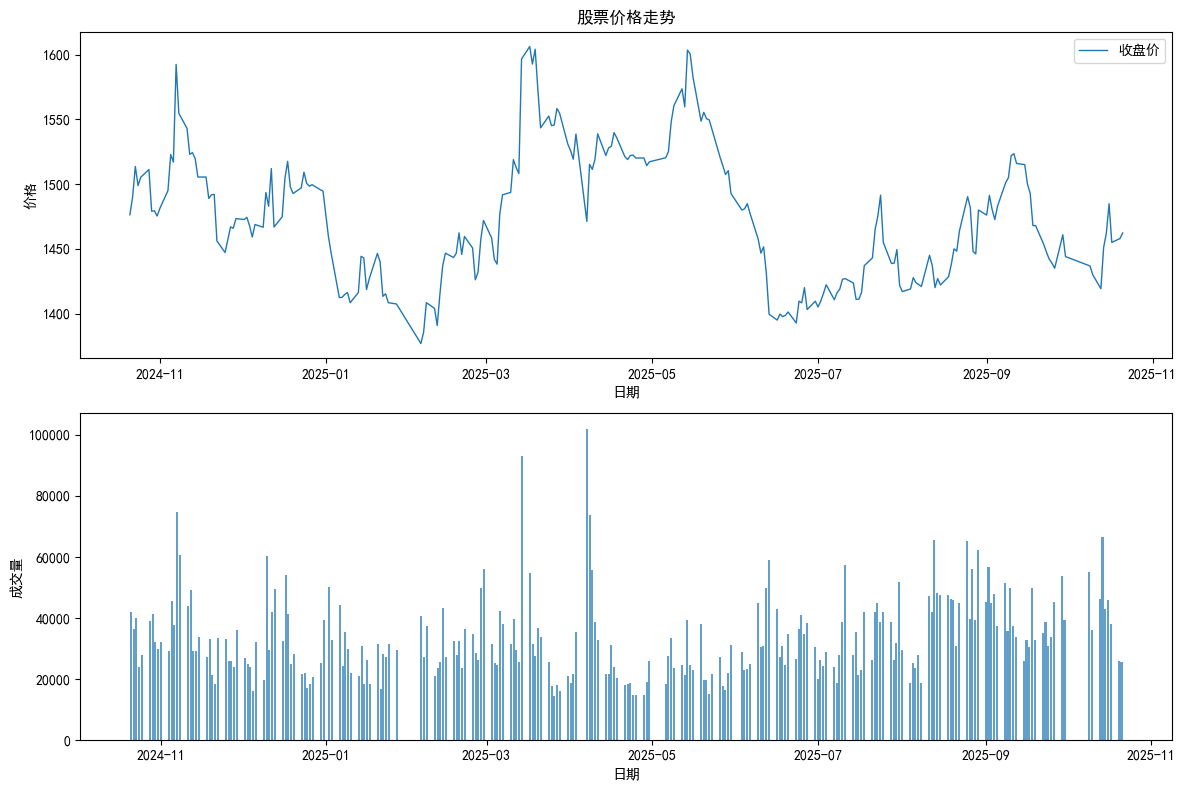

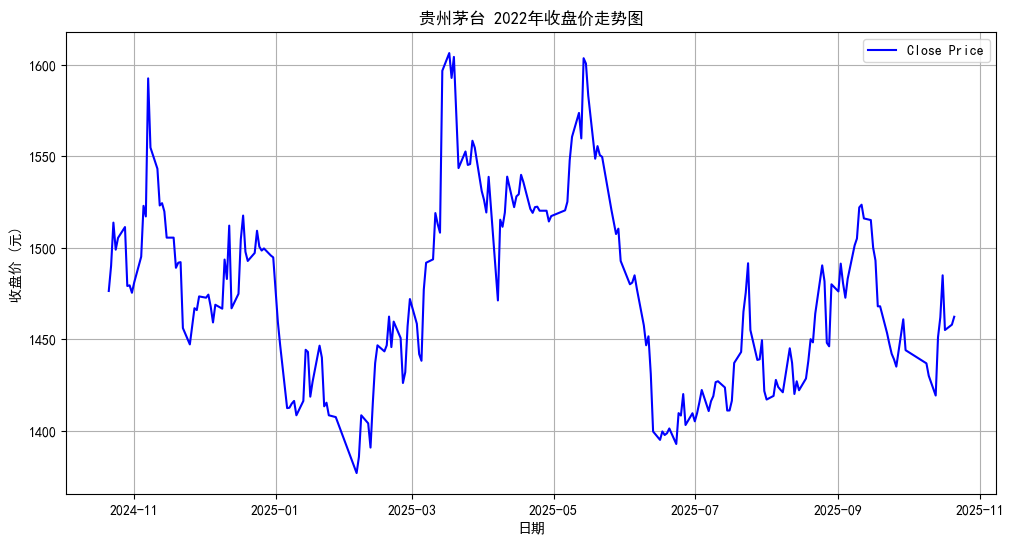

In [39]:
"""
Tushare获取单只股票的信息以及信息展示和组合投资的例子。
"""
import tushare as ts
import pandas as pd
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei'] 

# 设置时间范围：获取过去一年的数据
end_date = datetime.now().strftime('%Y%m%d')
start_date = (datetime.now() - timedelta(days=365)).strftime('%Y%m%d')

ts_code = '600519.SH' # 贵州茅台股票代码

# 调用daily接口获取日线数据
df_daily = ts.pro_bar(
    ts_code=ts_code,  # 贵州茅台股票代码
    asset='E',            # E表示股票
    start_date=start_date,
    end_date=end_date,
    adj='qfq'             # 复权方式：qfq前复权
)

# 解释关键字段
# trade_date: 交易日期
# open: 开盘价, high: 最高价, low: 最低价, close: 收盘价
# vol: 成交量（单位：手），amount: 成交额（单位：千元）

# 将交易日期转换为日期格式
df_daily['trade_date'] = pd.to_datetime(df_daily['trade_date'])
# 按日期排序
df_daily = df_daily.sort_values('trade_date')

# 对比接口说明：
# 1. ts.pro_bar() 是通用接口，可获取股票、基金、期货等数据
# 2. ts.daily() 是旧版股票日线接口（推荐使用pro_bar）

print("贵州茅台最近5个交易日数据：")
print(df_daily[['trade_date', 'open', 'close', 'vol']].head())


"""
股票数据可视化
"""
def visualize_stock_data(df, title="股票价格走势"):
    """
    可视化股票数据
    """
    if df is None or len(df) == 0:
        print("没有数据可可视化")
        return
    
    # 按日期排序
    df = df.sort_values('trade_date')
    
    # 创建图表
    plt.figure(figsize=(12, 8))
    
    # 绘制价格和移动平均线
    plt.subplot(2, 1, 1)
    plt.plot(df['trade_date'], df['close'], label='收盘价', linewidth=1)
    if 'ma5' in df.columns:
        plt.plot(df['trade_date'], df['ma5'], label='5日均线', linewidth=1)
    if 'ma20' in df.columns:
        plt.plot(df['trade_date'], df['ma20'], label='20日均线', linewidth=1)
    
    plt.title(title)
    plt.ylabel('价格')
    plt.xlabel('日期')
    plt.legend()

    
    
    # 绘制成交量
    plt.subplot(2, 1, 2)
    plt.bar(df['trade_date'], df['vol'], alpha=0.7)
    plt.ylabel('成交量')
    plt.xlabel('日期')

    
    plt.tight_layout()
    plt.show()

# 可视化股票价格数据
if df is not None:
    visualize_stock_data(df_daily,"股票价格走势")





In [6]:
"""
【示例7】stock_zh_a_daily获取历史数据。
"""
# 引入akshare模块，别名为ak
import akshare as ak

ak.stock_zh_a_daily(symbol="sz000001", start_date="20220101", end_date="20230101", adjust="qfq")




,date,open,high,low,close,volume,amount,outstanding_share,turnover
0,2022-01-04,14.44,14.59,14.17,14.59,116925933.0,1.918887e+09,1.940552e+10,0.006025
1,2022-01-05,14.52,15.08,14.50,15.02,196199817.0,3.344125e+09,1.940552e+10,0.010111
2,2022-01-06,14.99,15.13,14.89,15.00,110788519.0,1.896536e+09,1.940552e+10,0.005709
3,2022-01-07,14.98,15.14,14.94,15.07,112663070.0,1.937711e+09,1.940552e+10,0.005806
4,2022-01-10,15.15,15.26,14.92,15.06,90977401.0,1.563415e+09,1.940552e+10,0.004688
...,...,...,...,...,...,...,...,...,...
237,2022-12-26,11.58,11.63,11.33,11.39,79711987.0,1.021904e+09,1.940555e+10,0.004108
238,2022-12-27,11.48,11.79,11.48,11.69,88600412.0,1.160090e+09,1.940555e+10,0.004566
239,2022-12-28,11.73,11.93,11.59,11.72,79119198.0,1.042402e+09,1.940555e+10,0.004077
240,2022-12-29,11.65,11.71,11.46,11.62,66689009.0,8.651450e+08,1.940555e+10,0.003437


In [7]:
"""
【示例8】akshare.stock_zh_a_spot_em获取实盘数据。
"""
# 引入akshare模块
import akshare as ak
# 使用stock_zh_a_em()方法或是A股实盘数据
df = ak.stock_zh_a_spot_em()
df = df[['代码','名称','最新价','成交量']]
# 选取'代码','名称','最新价','成交量'字段的数据
print(df.head(2))


       代码   名称   最新价       成交量
0  688411  N海博  63.8  255795.0
1  001395  N亚联  49.5  147706.0


In [51]:
"""
【示例9】akshare获取沪深股市股票列表
"""
import akshare as ak

# 获取A股股票列表（沪市+深市）
stock_list = ak.stock_zh_a_spot_em()

# 关键字段解释：
# 代码：股票代码（如 600519）
# 名称：股票名称
# 最新价：当前股价
# 成交量：当日成交量（单位：手）
# 所属行业：行业分类

# 保存为CSV文件
stock_list.to_csv("./stock_list.csv", index=False, encoding="utf-8-sig")
print("股票列表已保存，共获取{}条记录".format(len(stock_list)))

股票列表已保存，共获取100条记录


In [46]:
"""
【示例10】akshare获取单支股票历史行情（贵州茅台）
"""
import akshare as ak

# 获取贵州茅台日线数据（参数：股票代码、开始/结束日期）
stock_daily = ak.stock_zh_a_daily(
    symbol="sh600519",  # 沪市股票代码前缀sh，深市sz
    start_date="20220101",
    end_date="20231231",
    adjust="hfq"        # hfq后复权，qfq前复权
)

# 关键字段解释：
# date：日期（自动转为datetime类型）
# open：开盘价
# high：最高价
# low：最低价
# close：收盘价
# volume：成交量（单位：手）

print("贵州茅台最近5天数据：")
print(stock_daily.head())

# 保存到Excel
stock_daily.to_excel('./600519_daily2.xlsx', index=False)

贵州茅台最近5天数据：
         date      open      high       low     close     volume  \
0  2022-01-04  15777.07  15884.17  15462.30  15748.13  3384262.0   
1  2022-01-05  15700.30  15853.85  15493.01  15539.07  2839551.0   
2  2022-01-06  15523.80  15631.20  14882.73  15218.31  5179475.0   
3  2022-01-07  15162.88  15269.44  14888.95  14909.53  2981669.0   
4  2022-01-10  14802.12  15178.24  14721.81  15093.78  2962670.0   

         amount  outstanding_share  turnover  
0  6.913653e+09       1.256198e+09  0.002694  
1  5.774992e+09       1.256198e+09  0.002260  
2  1.022693e+10       1.256198e+09  0.004123  
3  5.831695e+09       1.256198e+09  0.002374  
4  5.792738e+09       1.256198e+09  0.002358  


In [50]:
"""
【示例11】AKshare批量获取多支股票数据
"""
import akshare as ak
import pandas as pd

# 目标股票列表（平安银行、宁德时代、贵州茅台）
stock_codes = ["sz000001", "sz000063", "sh600519"]
all_data = pd.DataFrame()

for code in stock_codes:
    try:
        # 获取单支股票数据
        df = ak.stock_zh_a_daily(
            symbol=code,
            start_date="20230101",
            end_date="20231231",
            adjust="hfq"
        )
        
        # 检查列名并重置索引（关键修复点）
        if "date" not in df.columns:
            df = df.reset_index()  # 如果日期是索引，则转为列
            df = df.rename(columns={"index": "date"})  # 部分版本日期列为索引
        
        # 添加股票代码列
        df["股票代码"] = code
        
        # 合并数据
        all_data = pd.concat([all_data, df], ignore_index=True)
        print(f"成功获取 {code} 数据，当前总数: {len(all_data)}")
        
    except Exception as e:
        print(f"获取 {code} 失败，错误信息: {str(e)}")

# 保存到Excel
if not all_data.empty:
    all_data.to_excel("./stock_batch_data.xlsx", index=False)
    print("批量获取完成，总数据量：", len(all_data))
else:
    print("未获取到有效数据，请检查接口或参数！")

成功获取 sz000001 数据，当前总数: 242
成功获取 sz000063 数据，当前总数: 484
成功获取 sh600519 数据，当前总数: 726
批量获取完成，总数据量： 726


In [7]:
"""
【示例12】Alpha Vantage API获取IBM过去5年的年度和季度收入报表。
"""
# 引入request模块，解析返回的html内容。
import requests
# 获取Alpha Vantage INCOME_STATEMENT返回信息。
url = 'https://www.alphavantage.co/query?function=INCOME_STATEMENT&symbol=IBM&apikey=431CLFUMRL0M51ZV'
alpha_vantage_context = requests.get(url)
# 将返回的json信息转变为字典类型数据进行读取 
data = alpha_vantage_context.json()
data_dict = dict(data)
print(data_dict['annualReports'][0])


{'fiscalDateEnding': '2022-12-31', 'reportedCurrency': 'USD', 'grossProfit': '32687000000', 'totalRevenue': '60530000000', 'costOfRevenue': '27842000000', 'costofGoodsAndServicesSold': '385000000', 'operatingIncome': '6408000000', 'sellingGeneralAndAdministrative': '18609000000', 'researchAndDevelopment': '6567000000', 'operatingExpenses': '26279000000', 'investmentIncomeNet': 'None', 'netInterestIncome': '-1216000000', 'interestIncome': '162000000', 'interestExpense': '1216000000', 'nonInterestIncome': '365000000', 'otherNonOperatingIncome': '443000000', 'depreciation': '2407000000', 'depreciationAndAmortization': '2395000000', 'incomeBeforeTax': '1013000000', 'incomeTaxExpense': '-626000000', 'interestAndDebtExpense': '1216000000', 'netIncomeFromContinuingOperations': '1783000000', 'comprehensiveIncomeNetOfTax': '8134000000', 'ebit': '2229000000', 'ebitda': '4624000000', 'netIncome': '1639000000'}


In [8]:
"""
【示例13】缺失值处理：检查。
"""
"""
打开D盘的“stock_清洗.csv”文件，查看是否存在缺失值，如果存在缺失值，则用前一行的值替换。
"""
import pandas as pd 
# 打开'd:/stock_清洗.csv'文件，获取内部数据。
file = 'e:/Python金融量化分析数据文件/stock_清洗.csv'              # 改为相应文件的存储路径
df = pd.read_csv(file, encoding='utf-8-sig')
# 检查DataFrame对象内部全部数据列是否存在空值，如果某列存在空值，则该列返回True，否则返回False。
df.isna().any()


trade_date    False
open          False
close          True
high          False
low           False
code          False
dtype: bool

In [28]:
"""
【示例14】缺失值处理：替换。
"""
import pandas as pd 
import numpy as np
# 打开'd:/stock_清洗.csv'文件，获取内部数据。
file = 'e:/Python金融量化分析数据文件/stock_清洗.csv'              # 改为相应文件的存储路径
df = pd.read_csv(file, encoding='utf-8-sig')
#print(df)

df['close'] = np.where(df['close'].isna(), df['close'].shift(1), df['close'])
#print(df)
df.isna().any()


trade_date    False
open          False
close         False
high          False
low           False
code          False
dtype: bool

In [23]:
"""
【示例15】异常值处理：统计检查。
"""
# describe函数可以获取数据的统计指标，round(2)函数可以获取小数取2位的数据。
print(df.describe().round(2))


         open    high     low   close        volume        amount  \
count  242.00  242.00  242.00  242.00  2.420000e+02  2.420000e+02   
mean    12.23   12.39   12.07   12.23  1.146620e+08  1.594644e+09   
std      1.51    1.53    1.47    1.51  5.524666e+07  7.944295e+08   
min      9.21    9.32    9.11    9.22  4.152534e+07  4.767492e+08   
25%     11.04   11.18   10.95   11.06  8.000329e+07  1.081736e+09   
50%     12.30   12.42   12.08   12.28  9.916103e+07  1.422705e+09   
75%     13.22   13.38   13.00   13.26  1.342646e+08  1.863890e+09   
max     15.29   15.38   15.08   15.25  4.749276e+08  6.026007e+09   

       outstanding_share  turnover  
count       2.420000e+02    242.00  
mean        1.940553e+10      0.01  
std         1.251521e+04      0.00  
min         1.940552e+10      0.00  
25%         1.940552e+10      0.00  
50%         1.940555e+10      0.01  
75%         1.940555e+10      0.01  
max         1.940555e+10      0.02  


<Axes: >

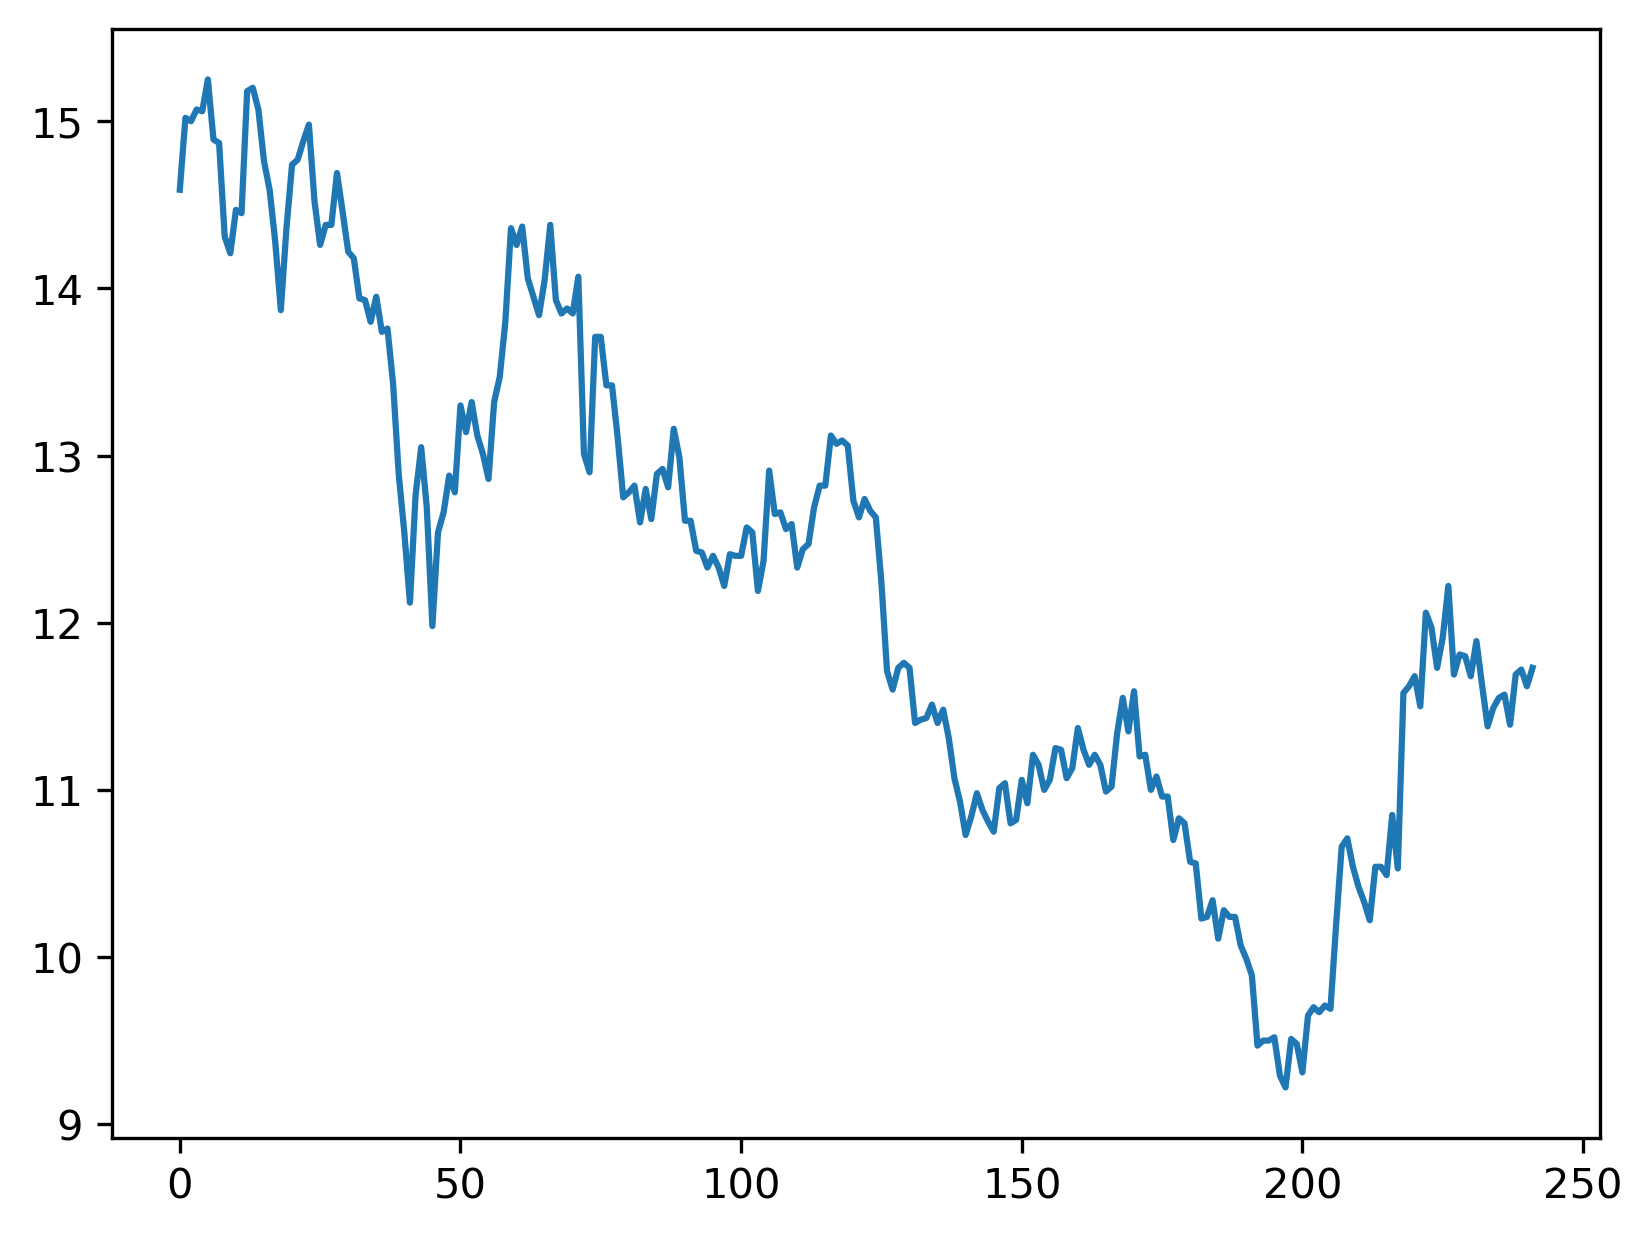

In [25]:
"""
【示例15修改】异常值处理：图形查看。
"""
import matplotlib.pyplot as plt
import pandas as pd
# plot()方法进行画图，可以清晰看出close列数据是否存在异常值。
# 设置清晰度
plt.rcParams['figure.dpi'] = 300
df['close'].plot()


C:\Users\35791\AppData\Local\Temp\ipykernel_9708\1707215226.py:9: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['close'].iloc[6] = df['close'].iloc[5]
C:\Users\35791\AppData\Local\Temp\ipykernel_9708\1707215226.py:9: SettingWithCopyWarnin

<Axes: >

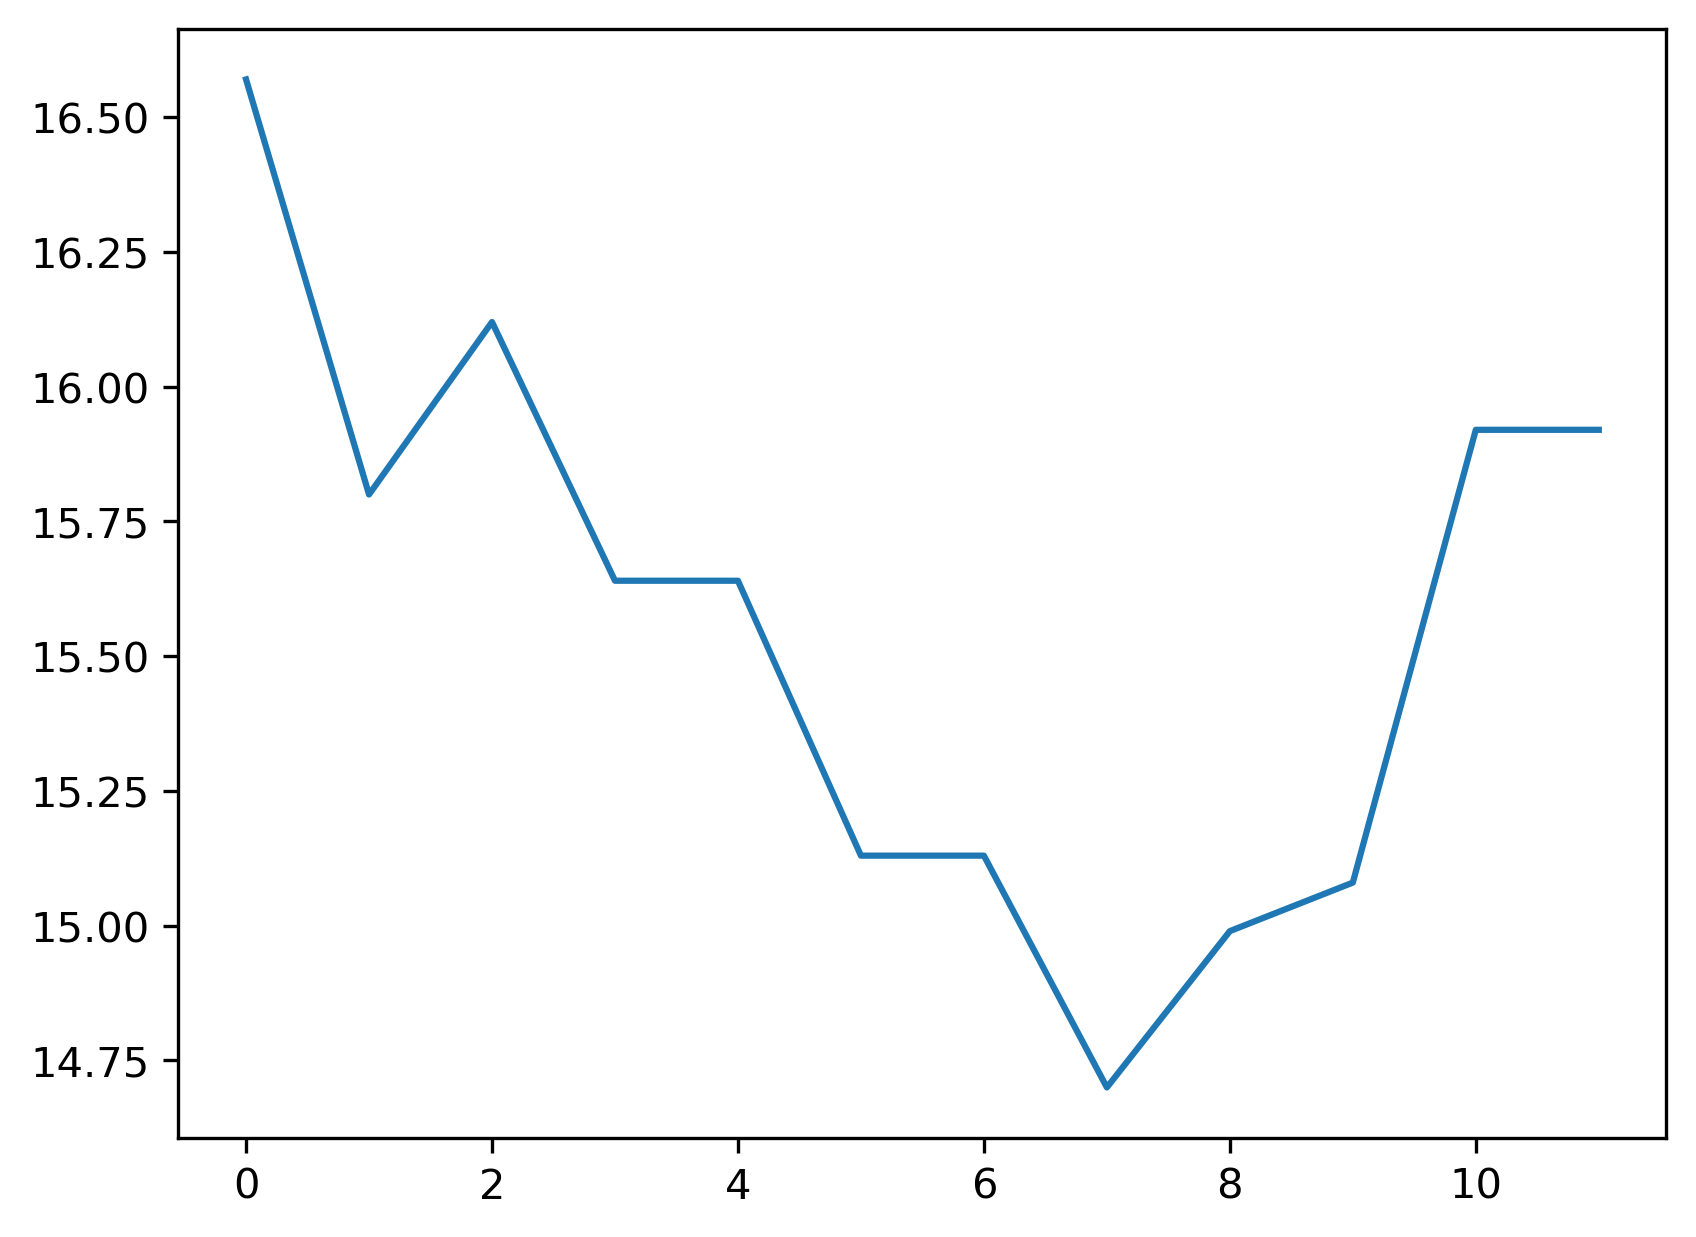

In [29]:
"""
【示例16】异常值处理：替换。
"""
import matplotlib.pyplot as plt
import pandas as pd
# 设置清晰度
plt.rcParams['figure.dpi'] = 300
# 将close列第6行数据替换为close列第5行数据
df['close'].iloc[6] = df['close'].iloc[5]
df['close'].plot()


In [30]:
"""
【示例17】重复值删除：检查。
"""
# 打印出DataFrame对象内部存在出现重复的行数据。
print(df[df.duplicated()])


   trade_date   open  close  high   low    code
11  2022/1/18  15.27  15.92  16.2  15.0  603959


In [31]:
"""
【示例18】重复值删除：删除。
"""
# 保留第1个值，返回删除一个。
df.drop_duplicates()


,trade_date,open,close,high,low,code
0,2022/1/4,16.11,16.57,16.93,15.90,603959
1,2022/1/5,16.58,15.80,16.78,15.80,603959
2,2022/1/6,15.82,16.12,16.32,15.51,603959
3,2022/1/7,16.09,15.64,16.29,15.60,603959
4,2022/1/10,14.08,15.64,16.10,14.08,603959
5,2022/1/11,15.71,15.13,15.84,15.10,603959
6,2022/1/12,15.21,15.13,15.43,15.11,603959
7,2022/1/13,15.33,14.70,15.37,14.60,603959
8,2022/1/14,14.69,14.99,15.25,14.63,603959
9,2022/1/17,14.86,15.08,15.21,14.86,603959


In [ ]:
"""
【示例19】重复值删除：删除。
"""
import pandas as pd
import numpy as np

# 读取案例2保存的贵州茅台数据（假设已存在）
df = pd.read_excel('./600519_daily.xlsx')

# 模拟缺失数据：随机删除5行
np.random.seed(42)  # 固定随机种子保证可重复性
drop_indices = np.random.choice(df.index, 5, replace=False)
df_missing = df.drop(drop_indices)

# 检查缺失值
print("缺失值数量：")
print(df_missing.isnull().sum())  # 查看各列缺失情况

# 方法1：前向填充（用前一天的数据填充当天缺失值）
df_filled_ffill = df_missing.fillna(method='ffill')

# 方法2：删除包含缺失值的行
df_dropped = df_missing.dropna()

# 对比处理结果
print("\n原始数据行数：", len(df))
print("模拟缺失后行数：", len(df_missing))
print("前向填充后行数：", len(df_filled_ffill))
print("删除缺失行后行数：", len(df_dropped))

# 保存处理后的数据
df_filled_ffill.to_excel('./600519_cleaned.xlsx', index=False)

In [9]:
"""
【示例】处理缺失值（贵州茅台数据示例）
"""
import pandas as pd
import numpy as np

# 读取案例2保存的贵州茅台数据（假设已存在）
df = pd.read_excel('./600519_daily.xlsx')

# 模拟缺失数据：随机删除5行
np.random.seed(42)  # 固定随机种子保证可重复性
drop_indices = np.random.choice(df.index, 5, replace=False)
df_missing = df.drop(drop_indices)

# 检查缺失值
print("缺失值数量：")
print(df_missing.isnull().sum())  # 查看各列缺失情况

# 方法1：前向填充（用前一天的数据填充当天缺失值）
df_filled_ffill = df_missing.fillna(method='ffill')

# 方法2：删除包含缺失值的行
df_dropped = df_missing.dropna()

# 对比处理结果
print("\n原始数据行数：", len(df))
print("模拟缺失后行数：", len(df_missing))
print("前向填充后行数：", len(df_filled_ffill))
print("删除缺失行后行数：", len(df_dropped))

# 保存处理后的数据
df_filled_ffill.to_excel('./600519_cleaned.xlsx', index=False)

缺失值数量：
ts_code       0
trade_date    0
open          0
high          0
low           0
close         0
pre_close     0
change        0
pct_chg       0
vol           0
amount        0
dtype: int64

原始数据行数： 242
模拟缺失后行数： 237
前向填充后行数： 237
删除缺失行后行数： 237


C:\Users\35791\AppData\Local\Temp\ipykernel_11384\3191781162.py:17: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled_ffill = df_missing.fillna(method='ffill')


In [10]:
"""
【示例】处理异常值（识别异常波动）
"""
import pandas as pd

# 读取清洗后的数据
df = pd.read_excel('./600519_cleaned.xlsx')

# 计算涨跌幅（如果原数据没有pct_chg字段）
# 注意：Tushare的daily接口原本包含pct_chg字段，此处为教学演示计算方法
df['pct_chg'] = (df['close'] / df['pre_close'] - 1) * 100

# 识别异常值：涨跌幅超过±10%（中国股市正常涨跌停限制为10%）
abnormal_data = df[(df['pct_chg'] < -10) | (df['pct_chg'] > 10)]

# 展示异常数据
if not abnormal_data.empty:
    print("发现异常波动数据：")
    print(abnormal_data[['trade_date', 'close', 'pct_chg']])
else:
    print("未发现异常波动数据")

# 方法1：直接过滤异常值
df_clean = df[(df['pct_chg'] >= -10) & (df['pct_chg'] <= 10)]

# 方法2：使用3σ原则处理（扩展知识）
mean = df['pct_chg'].mean()
std = df['pct_chg'].std()
df_3sigma = df[(df['pct_chg'] >= mean-3*std) & (df['pct_chg'] <= mean+3*std)]

print("\n过滤后数据量：", len(df_clean))
print("3σ原则过滤后数据量：", len(df_3sigma))

未发现异常波动数据

过滤后数据量： 237
3σ原则过滤后数据量： 231


In [11]:
"""
【示例】数据格式转换（日期与单位转换）
"""
import pandas as pd

# 读取数据（以案例4处理后的数据为例）
df = pd.read_excel('./600519_cleaned.xlsx')

# 转换日期格式
df['trade_date'] = pd.to_datetime(
    df['trade_date'], 
    format='%Y%m%d',       # 原始格式是年月日数字字符串
    errors='coerce'        # 错误日期转为NaT
).dt.strftime('%Y-%m-%d')  # 转换为标准日期格式字符串

# 转换成交量单位：手→万股（1手=100股，1万股=10000股）
df['vol_wan'] = df['vol'] / 100  # vol单位是手，100手=1万股
df['vol_wan'] = df['vol_wan'].round(2)  # 保留两位小数

# 重命名列（可选）
df = df.rename(columns={'vol': 'vol_hand'})

# 验证转换结果
print("转换后数据类型：")
print(df.dtypes)

print("\n转换示例：")
print(df[['trade_date', 'vol_hand', 'vol_wan']].head(3))

转换后数据类型：
ts_code        object
trade_date     object
open          float64
high          float64
low           float64
close         float64
pre_close     float64
change        float64
pct_chg       float64
vol_hand      float64
amount        float64
vol_wan       float64
dtype: object

转换示例：
   trade_date  vol_hand  vol_wan
0  2024-04-10  27630.50   276.30
1  2024-04-11  22766.24   227.66
2  2024-04-12  26744.33   267.44


In [21]:
"""
【示例20】stock_zh_a_daily获取历史数据。
"""
# 引入akshare模块，别名为ak
import akshare as ak
import pandas as pd

df = ak.stock_zh_a_daily(symbol="sz000001", start_date="20220101", end_date="20230101", adjust="qfq")

df.to_csv('e:/Python金融量化分析数据文件/stock_保存_test.csv',index=False)   # 写上保存路径和文件名
print(df)

           date   open   high    low  close       volume        amount  \
0    2022-01-04  14.44  14.59  14.17  14.59  116925933.0  1.918887e+09   
1    2022-01-05  14.52  15.08  14.50  15.02  196199817.0  3.344125e+09   
2    2022-01-06  14.99  15.13  14.89  15.00  110788519.0  1.896536e+09   
3    2022-01-07  14.98  15.14  14.94  15.07  112663070.0  1.937711e+09   
4    2022-01-10  15.15  15.26  14.92  15.06   90977401.0  1.563415e+09   
..          ...    ...    ...    ...    ...          ...           ...   
237  2022-12-26  11.58  11.63  11.33  11.39   79711987.0  1.021904e+09   
238  2022-12-27  11.48  11.79  11.48  11.69   88600412.0  1.160090e+09   
239  2022-12-28  11.73  11.93  11.59  11.72   79119198.0  1.042402e+09   
240  2022-12-29  11.65  11.71  11.46  11.62   66689009.0  8.651450e+08   
241  2022-12-30  11.63  11.84  11.56  11.73   81803598.0  1.074757e+09   

     outstanding_share  turnover  
0         1.940552e+10  0.006025  
1         1.940552e+10  0.010111  
2     

In [22]:
"""
【示例21】获取JSON数据。
"""
import requests 
url = 'https://www.alphavantage.co/query?function=TIME_SERIES_DAILY_ADJUSTED&symbol=AAPL&outputsize=compact&apikey=YOUR_API_KEY&apikey=YOUR_API_KEY '
result = requests.get(url)
data = result.json()
print(data)


{'Information': 'Thank you for using Alpha Vantage! This is a premium endpoint. You may subscribe to any of the premium plans at https://www.alphavantage.co/premium/ to instantly unlock all premium endpoints'}


In [18]:
"""
【示例22】解析JSON数据。
"""
import pandas as pd 
# 读取“Time Series (Daily)”键对应的值，以获取全部日线交易数据。
data_daily = data['Time Series (Daily)']
# 设置存储每日日线交易数据OHLC数据值的列表。
daily_ohlc_list = []
# 设置存储每日日线交易数据的字典。
daily_ohlc = {}
# 设置存储全部日期日线交易数据的列表，为生成pd.DataFrmae做准备。
daily_ohlc_all = []
# data_daily为字典类型数据，index为日期，value为每日的open、high、low、close、justed_close、volume等数据。
for index,value in data_daily.items():
    # 将每日日期存储与没日线交易数据字典中的datetime键值。
    daily_ohlc['datetime'] = index
    # 将每日的OHLC数据保存如daily_ohlc_list列表中。
    for value_ohlc in value.values():   
        daily_ohlc_list.append(value_ohlc)
    # 在每日日线交易数据字典变量内部添加open、high、low、close、adj_close与volume键值对数据。
    daily_ohlc['open'] = daily_ohlc_list[0]
    daily_ohlc['high'] = daily_ohlc_list[1]
    daily_ohlc['low'] = daily_ohlc_list[2]
    daily_ohlc['close'] = daily_ohlc_list[3]
    daily_ohlc['adj_close'] = daily_ohlc_list[4]
    daily_ohlc['volume'] = daily_ohlc_list[5]
    # 将每日日线交易数据字典数据添加至daily_ohlc_all列表内。
    daily_ohlc_all.append(daily_ohlc)
# 利用列表类型变量daily_ohlc_all生成pandas.DataFrame对象，实现数据清洗
df  = pd.DataFrame(daily_ohlc_all)
print(df)


      datetime    open    high     low   close adj_close    volume
0   2023-01-10  181.03  181.78  179.26  180.95    180.95  61996913
1   2023-01-10  181.03  181.78  179.26  180.95    180.95  61996913
2   2023-01-10  181.03  181.78  179.26  180.95    180.95  61996913
3   2023-01-10  181.03  181.78  179.26  180.95    180.95  61996913
4   2023-01-10  181.03  181.78  179.26  180.95    180.95  61996913
..         ...     ...     ...     ...     ...       ...       ...
95  2023-01-10  181.03  181.78  179.26  180.95    180.95  61996913
96  2023-01-10  181.03  181.78  179.26  180.95    180.95  61996913
97  2023-01-10  181.03  181.78  179.26  180.95    180.95  61996913
98  2023-01-10  181.03  181.78  179.26  180.95    180.95  61996913
99  2023-01-10  181.03  181.78  179.26  180.95    180.95  61996913

[100 rows x 7 columns]


In [21]:
"""
【示例23】数据保存CSV格式文件。
"""
# 该代码将pandas.DataFrame类型的df变量保存的数据内容存储至“d:/test/data.csv”。
df.to_csv('d:/test/data.csv',encoding='utf-8-sig', index=False)


In [36]:
"""
【示例24】创建SQLite数据库文件。
"""
# 引入sqlite3模块
import sqlite3
import pandas as pd

# 创建一个SQLite数据库600000.db连接，如果没有该文件则新建此文件。
conn = sqlite3.connect('e:/Python金融量化分析数据文件/stock_数据库保存_test.db')

# 创建一个游标对象。
cursor = conn.cursor()

# 创建一个名为stocks的表来存储股票数据。
cursor.execute("""
                CREATE TABLE IF NOT EXISTS stocks (
                    symbol TEXT,
                    date TEXT,
                    open REAL,
                    high REAL,
                    low REAL,
                    close REAL,
                    volume INTEGER)
                    """)
conn.commit()


In [37]:
"""
【示例25】将数据保存至SQLite数据库。

"""
# 假设我们有一个包含股票数据的pandas DataFrame
data = {
    'symbol': ['PFYH', 'PFYH', 'PFYH'],
    'date': ['2023-04-16', '2023-04-17', '2023-04-18'],
    'open': [7.28, 7.26, 7.38],
    'high': [7.31, 7.4, 7.59],
    'low': [7.25, 7.26, 7.37],
    'close': [7.27, 7.39, 7.54],
    'volume': [1000000, 2000000, 3000000]
}
df = pd.DataFrame(data)
# 将DataFrame中的数据插入到stocks表中
df.to_sql('stocks', conn, if_exists='append', index=False, method='multi')



3

In [38]:
"""
【示例26】SQLite数据查询。
"""
# 查询stocks表中的所有数据
cursor.execute("SELECT * FROM stocks")
rows = cursor.fetchall()

# 将查询结果转换为DataFrame
result_df = pd.DataFrame(rows, columns=['symbol', 'date', 'open', 'high', 'low', 'close', 'volume'])
print(result_df)


  symbol        date  open  high   low  close   volume
0   PFYH  2023-04-16  7.28  7.31  7.25   7.27  1000000
1   PFYH  2023-04-17  7.26  7.40  7.26   7.39  2000000
2   PFYH  2023-04-18  7.38  7.59  7.37   7.54  3000000


In [39]:
"""
【示例27】关闭SQLite数据库连接。
"""
# 关闭数据库连接
cursor.close()
conn.close()


In [33]:
"""
【综合例子1.1】使用Matplotlib和Seaborn库来绘制股票价格和交易量的时间序列图，并添加移动平均线等辅助线。
"""
import tushare as ts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 设置Tushare的token（需要注册Tushare账号获取）
ts.set_token('')
pro = ts.pro_api()


# 获取股票数据
# 使用Tushare获取某只股票的历史交易数据。这里以“贵州茅台”（股票代码：600519）为例
# 获取贵州茅台的历史日线数据
df = pro.daily(ts_code='600519.SH', start_date='20220101', end_date='20221231')

# 查看数据的前几行
print(df.head())

# 数据探索与初步分析,先对数据进行一些基本的探索性分析
# 查看数据的基本信息
print(df.info())

# 查看数据的统计摘要
print(df.describe())

# 检查是否有缺失值
print(df.isnull().sum())



     ts_code trade_date     open     high      low    close  pre_close  \
0  600519.SH   20221230  1736.00  1752.99  1727.00  1727.00    1719.00   
1  600519.SH   20221229  1717.00  1726.99  1701.05  1719.00    1733.00   
2  600519.SH   20221228  1745.88  1747.00  1708.01  1733.00    1733.00   
3  600519.SH   20221227  1738.00  1747.15  1725.50  1733.00    1720.15   
4  600519.SH   20221226  1771.00  1771.00  1735.02  1742.06    1771.00   

   change  pct_chg       vol       amount  
0    8.00   0.4654  25333.12  4409544.297  
1  -14.00  -0.8078  22417.80  3844499.655  
2    0.00   0.0000  21437.90  3699948.995  
3   12.85   0.7470  17905.05  3109270.166  
4  -28.94  -1.6341  21383.80  3749121.030  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   ts_code     242 non-null    object 
 1   trade_date  242 non-null    object 
 2   open        242 n

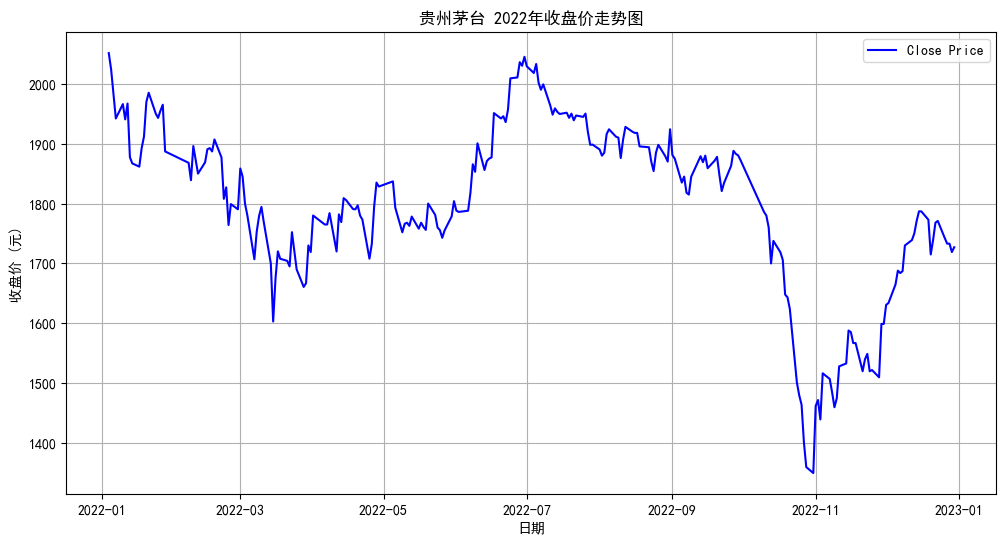

In [34]:
"""
【综合例子1.2】使用Matplotlib和Seaborn库来绘制股票价格和交易量的时间序列图，并添加移动平均线等辅助线。
"""
# 数据可视化: 绘制股票价格的时间序列图
# 将交易日期转换为日期格式
df['trade_date'] = pd.to_datetime(df['trade_date'])

# 按日期排序
df = df.sort_values('trade_date')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei'] 
# 绘制股票收盘价的时间序列图
plt.figure(figsize=(12, 6))
plt.plot(df['trade_date'], df['close'], label='Close Price', color='blue')
plt.title('贵州茅台 2022年收盘价走势图')
plt.xlabel('日期')
plt.ylabel('收盘价 (元)')
plt.legend()
plt.grid(True)
plt.show()


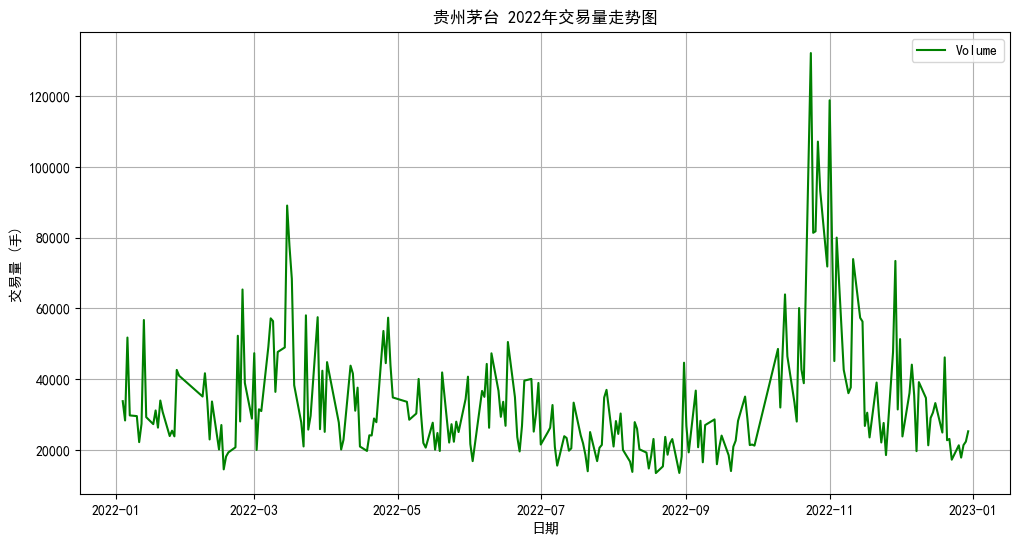

In [15]:
"""
【综合例子1.3】使用Matplotlib和Seaborn库来绘制股票价格和交易量的时间序列图，并添加移动平均线等辅助线。
"""
# 数据可视化
# 绘制交易量的时间序列图
plt.figure(figsize=(12, 6))
plt.plot(df['trade_date'], df['vol'], label='Volume', color='green')
plt.title('贵州茅台 2022年交易量走势图')
plt.xlabel('日期')
plt.ylabel('交易量 (手)')
plt.legend()
plt.grid(True)
plt.show()


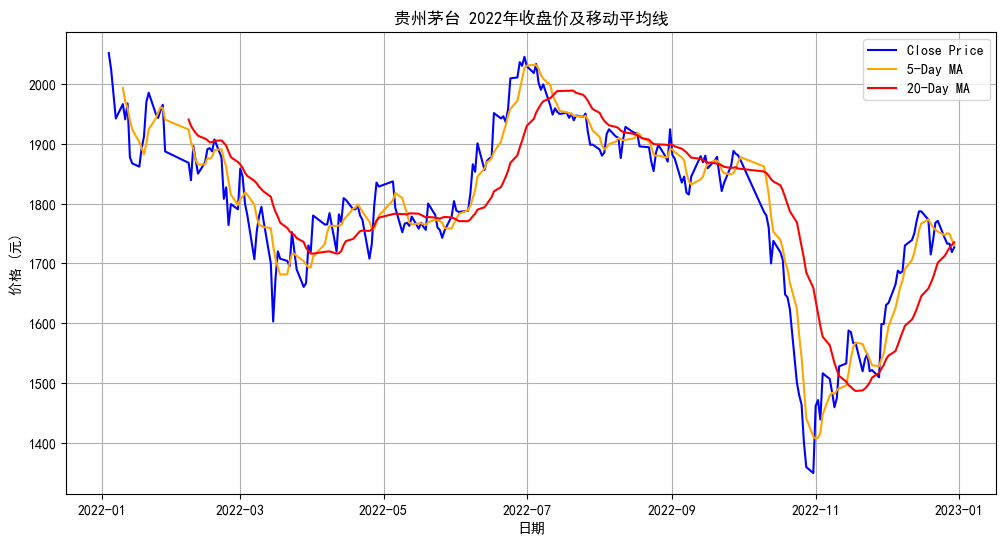

In [16]:
"""
【综合例子1.4】使用Matplotlib和Seaborn库来绘制股票价格和交易量的时间序列图，并添加移动平均线等辅助线。
"""
# 数据可视化: 添加移动平均线
# 移动平均线是常用的技术分析工具，可以帮助我们更好地理解股价的趋势。这里我们计算并绘制5日和20日的移动平均线。
# 计算5日和20日的移动平均线
df['MA5'] = df['close'].rolling(window=5).mean()
df['MA20'] = df['close'].rolling(window=20).mean()

# 绘制收盘价和移动平均线
plt.figure(figsize=(12, 6))
plt.plot(df['trade_date'], df['close'], label='Close Price', color='blue')
plt.plot(df['trade_date'], df['MA5'], label='5-Day MA', color='orange')
plt.plot(df['trade_date'], df['MA20'], label='20-Day MA', color='red')
plt.title('贵州茅台 2022年收盘价及移动平均线')
plt.xlabel('日期')
plt.ylabel('价格 (元)')
plt.legend()
plt.grid(True)
plt.show()


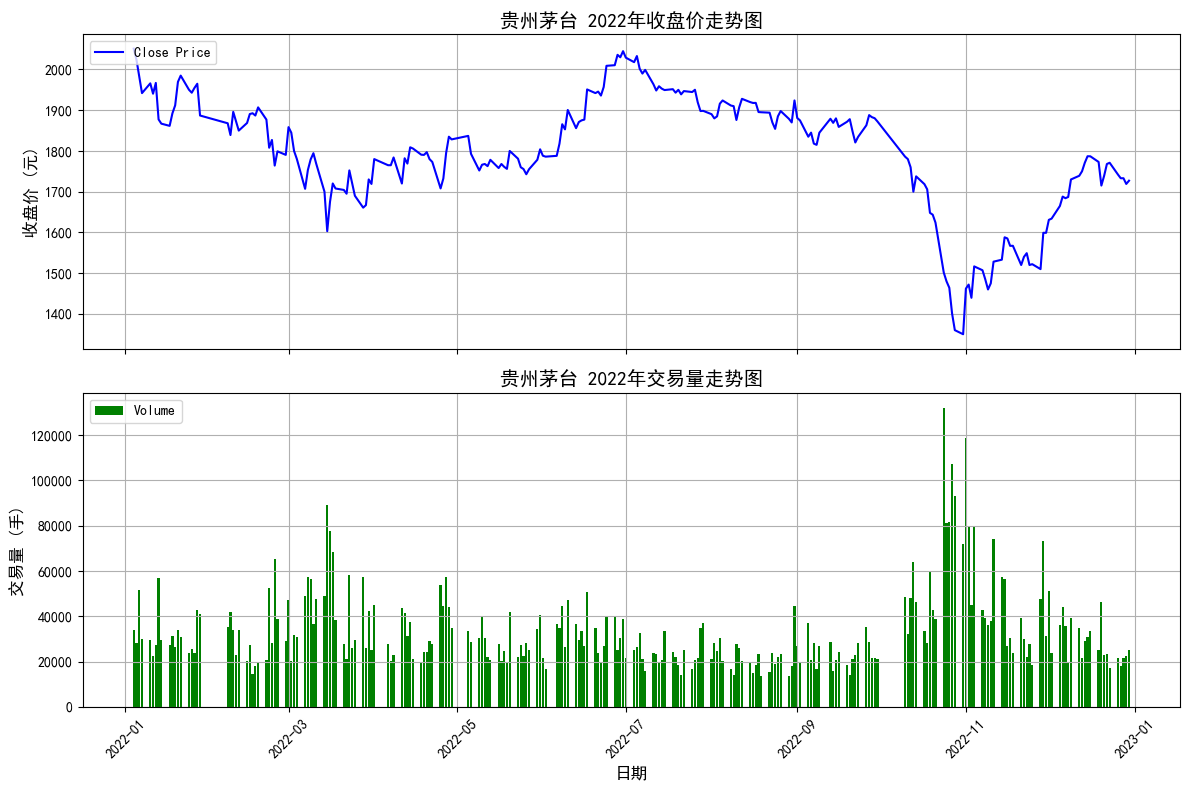

In [20]:
"""
【综合例子2】使用Seaborn绘制股票价格和交易量的联合图
"""
import tushare as ts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置Tushare的token（需要注册Tushare账号获取）
ts.set_token('')
pro = ts.pro_api()

# 获取贵州茅台的历史日线数据
df = pro.daily(ts_code='600519.SH', start_date='20220101', end_date='20221231')

# 将交易日期转换为日期格式
df['trade_date'] = pd.to_datetime(df['trade_date'])

# 按日期排序
df = df.sort_values('trade_date')

# 创建子图，设置布局为2行1列
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# 第一幅子图：绘制股票收盘价
sns.lineplot(x='trade_date', y='close', data=df, label='Close Price', color='blue', ax=ax1)
ax1.set_title('贵州茅台 2022年收盘价走势图', fontsize=14)
ax1.set_ylabel('收盘价 (元)', fontsize=12)
ax1.legend(loc='upper left')
ax1.grid(True)

# 第二幅子图：绘制交易量（柱状图）
ax2.bar(df['trade_date'], df['vol'], color='green', label='Volume')
ax2.set_title('贵州茅台 2022年交易量走势图', fontsize=14)
ax2.set_xlabel('日期', fontsize=12)
ax2.set_ylabel('交易量 (手)', fontsize=12)
ax2.legend(loc='upper left')
ax2.grid(True)

# 调整x轴日期显示格式，避免重叠
plt.xticks(rotation=45)

# 调整子图之间的间距
plt.tight_layout()

# 显示图形
plt.show()


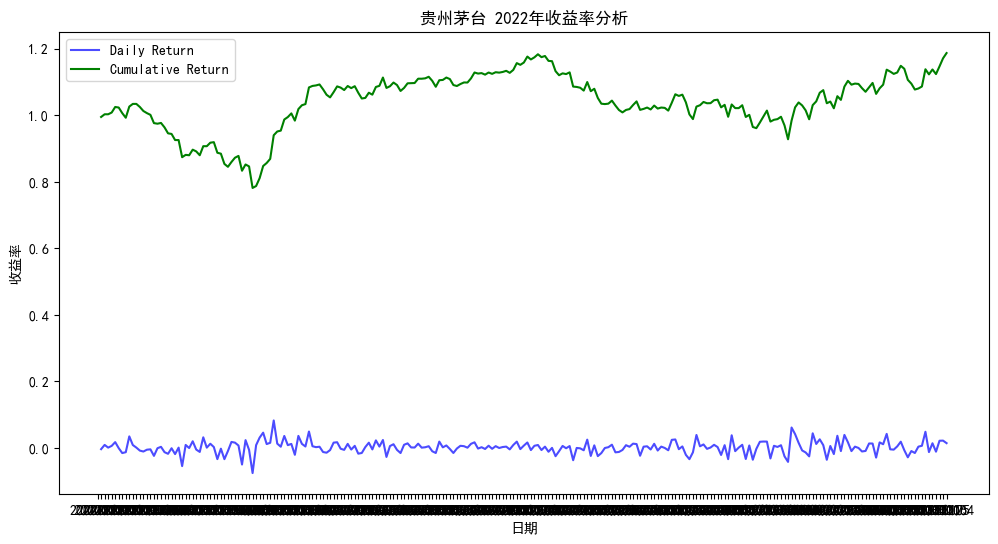

In [25]:
"""
【综合例子3】
股票收益率分析
内容：收益率是衡量股票投资回报的重要指标，可以帮助分析股票的风险和收益特征。
例子：
计算每日收益率、累计收益率。
绘制收益率的时间序列图。
思考一下：
1. x轴的坐标为什么是黑乎乎的一片？如何调整代码？
2. Daily Return和Cumulativ Return数值相差过大，导致Daily reuturn看起来像是直线。如何修改？
3. 如何分析收益率的分布。
"""
import tushare as ts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置Tushare的token（需要注册Tushare账号获取）
ts.set_token('')
pro = ts.pro_api()

# 获取贵州茅台的历史日线数据
df = pro.daily(ts_code='600519.SH', start_date='20220101', end_date='20221231')

# 计算每日收益率
df['daily_return'] = df['close'].pct_change()

# 计算累计收益率
df['cumulative_return'] = (1 + df['daily_return']).cumprod()

# 绘制每日收益率和累计收益率
plt.figure(figsize=(12, 6))
plt.plot(df['trade_date'], df['daily_return'], label='Daily Return', color='blue', alpha=0.7)
plt.plot(df['trade_date'], df['cumulative_return'], label='Cumulative Return', color='green')
plt.title('贵州茅台 2022年收益率分析')
plt.xlabel('日期')
plt.ylabel('收益率')
plt.legend()
# plt.grid(True)
plt.show()




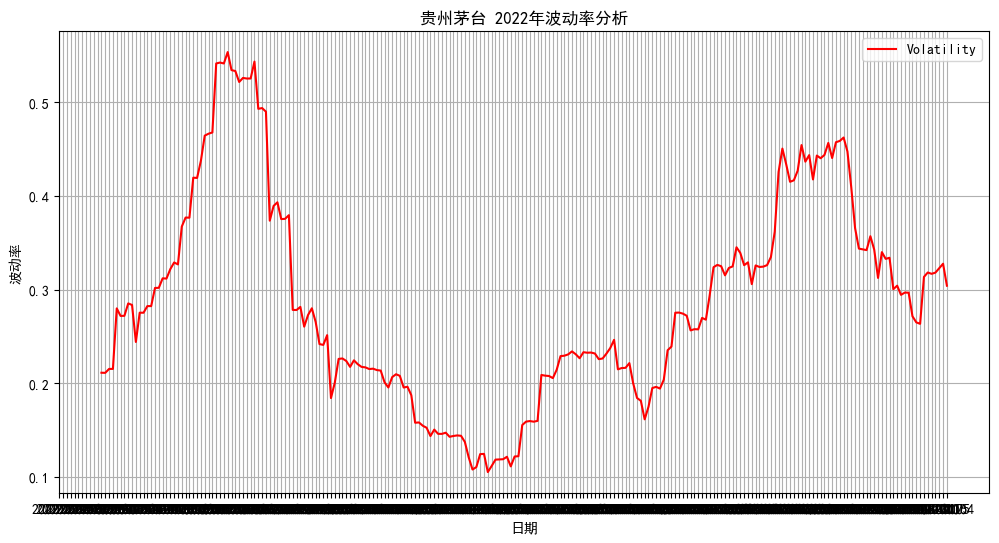

In [30]:
"""
【综合例子4】
股票波动率分析
内容：波动率是衡量股票价格波动程度的指标，可以帮助评估股票的风险。
例子：
计算历史波动率。
绘制波动率的时间序列图，分析波动率的变化趋势。
思考一下：
1. x轴的坐标为什么是黑乎乎的一片？如何调整代码？
2. 如果加网格的话，网格会太密集，如何修改？
3. 年化波动率的计算公式是什么？年化波动率对于股票市场有什么指导意义？
"""

# 计算历史波动率（以20日为窗口）
df['volatility'] = df['daily_return'].rolling(window=20).std() * (252 ** 0.5)  # 年化波动率

# 绘制波动率
plt.figure(figsize=(12, 6))
plt.plot(df['trade_date'], df['volatility'], label='Volatility', color='red')
plt.title('贵州茅台 2022年波动率分析')
plt.xlabel('日期')
plt.ylabel('波动率')
plt.legend()
plt.grid(True)
plt.show()


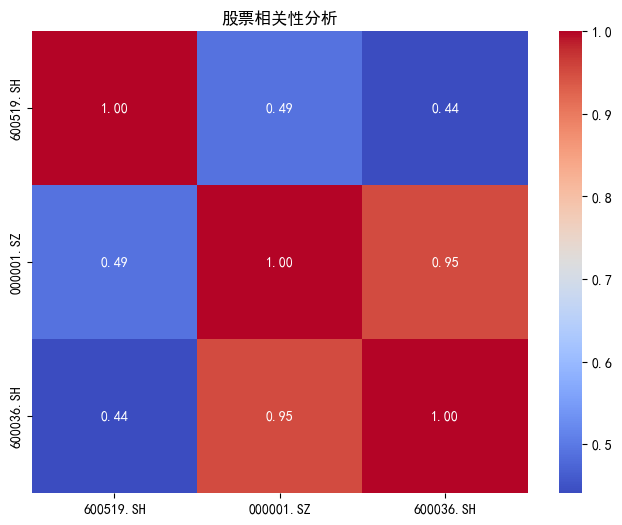

In [32]:
"""
【综合例子5】
 股票相关性分析
内容：分析不同股票之间的相关性，可以帮助构建投资组合，降低风险。
例子：
获取多只股票的历史数据，计算它们之间的相关性。
绘制相关性热力图。
思考一下：
1. 能否将所有股票，比如一年内5000只股票做相关性分析？
2. 是否相关性高的股票属于同一个板块或者类别？
3. 有没有更好的相关性研究方法？
"""
import tushare as ts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置Tushare的token（需要注册Tushare账号获取）
ts.set_token('')
pro = ts.pro_api()


# 获取多只股票的历史数据
stock_codes = ['600519.SH', '000001.SZ', '600036.SH']  # 贵州茅台、平安银行、招商银行
data = {}
for code in stock_codes:
    df_temp = pro.daily(ts_code=code, start_date='20220101', end_date='20221231')
    df_temp['trade_date'] = pd.to_datetime(df_temp['trade_date'])
    df_temp = df_temp.set_index('trade_date')
    data[code] = df_temp['close']

# 合并数据
df_stocks = pd.DataFrame(data)

# 计算相关性
correlation = df_stocks.corr()

# 绘制相关性热力图
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('股票相关性分析')
plt.show()


       ts_code trade_date     open     high      low    close  pre_close  \
0    600519.SH   20221230  1736.00  1752.99  1727.00  1727.00    1719.00   
1    600519.SH   20221229  1717.00  1726.99  1701.05  1719.00    1733.00   
2    600519.SH   20221228  1745.88  1747.00  1708.01  1733.00    1733.00   
3    600519.SH   20221227  1738.00  1747.15  1725.50  1733.00    1720.15   
4    600519.SH   20221226  1771.00  1771.00  1735.02  1742.06    1771.00   
..         ...        ...      ...      ...      ...      ...        ...   
237  600519.SH   20220110  1928.01  1977.00  1917.55  1966.00    1942.00   
238  600519.SH   20220107  1975.00  1988.88  1939.32  1942.00    1982.22   
239  600519.SH   20220106  2022.01  2036.00  1938.51  1982.22    2024.00   
240  600519.SH   20220105  2045.00  2065.00  2018.00  2024.00    2051.23   
241  600519.SH   20220104  2055.00  2068.95  2014.00  2051.23    2050.00   

     change  pct_chg       vol        amount  daily_return  cumulative_return  \
0     

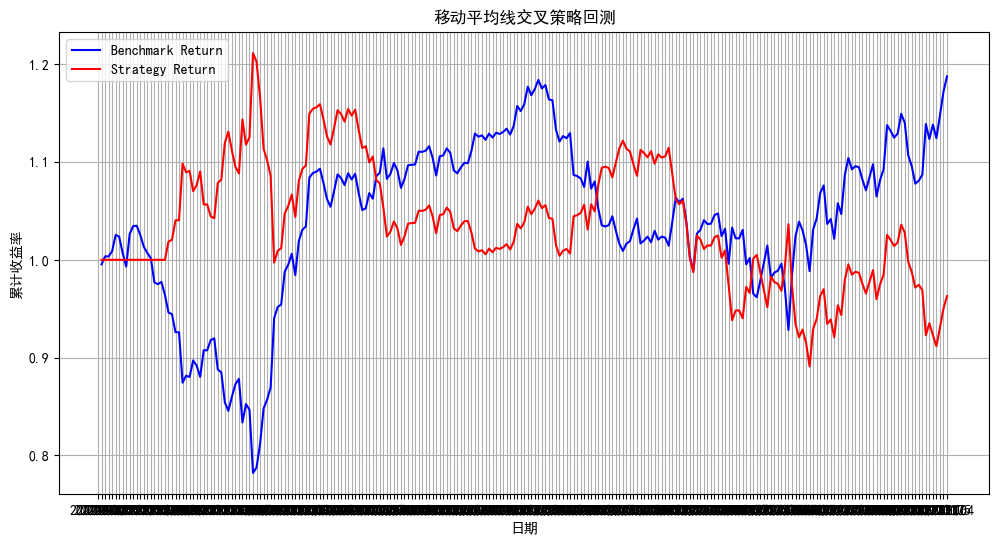

In [39]:
"""
【综合例子6】
股票交易策略回测
内容：通过简单的交易策略回测，展示量化分析的实际应用。
例子：
基于移动平均线的交叉策略（如5日均线上穿20日均线时买入，下穿时卖出）。
计算策略的收益率，并与基准收益率进行比较。
思考一下：
1. 假如我们是收盘价5日均线上穿20日均线第二天开盘价买入，应该如何改进这个策略？
2. 试试其他股票，如果采用相同的策略，结果如何？
"""
import tushare as ts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置Tushare的token（需要注册Tushare账号获取）
ts.set_token('')
pro = ts.pro_api()

# 计算5日和20日的移动平均线
df['MA5'] = df['close'].rolling(window=5).mean()
df['MA20'] = df['close'].rolling(window=20).mean()

# 计算每日收益率
df['daily_return'] = df['close'].pct_change()
# 计算信号
df['signal'] = 0
df.loc[df['MA5'] > df['MA20'], 'signal'] = 1  # 买入信号
df.loc[df['MA5'] < df['MA20'], 'signal'] = -1  # 卖出信号

# 计算策略收益率
df['strategy_return'] = df['signal'].shift(1) * df['daily_return']
print(df)
# 计算累计收益率
df['strategy_cumulative_return'] = (1 + df['strategy_return']).cumprod()
# 计算Benchmark的累计收益率
df['cumulative_return'] = (1 + df['daily_return']).cumprod()

# 绘制策略收益率和基准收益率
plt.figure(figsize=(12, 6))
plt.plot(df['trade_date'], df['cumulative_return'], label='Benchmark Return', color='blue')
plt.plot(df['trade_date'], df['strategy_cumulative_return'], label='Strategy Return', color='red')
plt.title('移动平均线交叉策略回测')
plt.xlabel('日期')
plt.ylabel('累计收益率')
plt.legend()
plt.grid(True)
plt.show()


D:\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


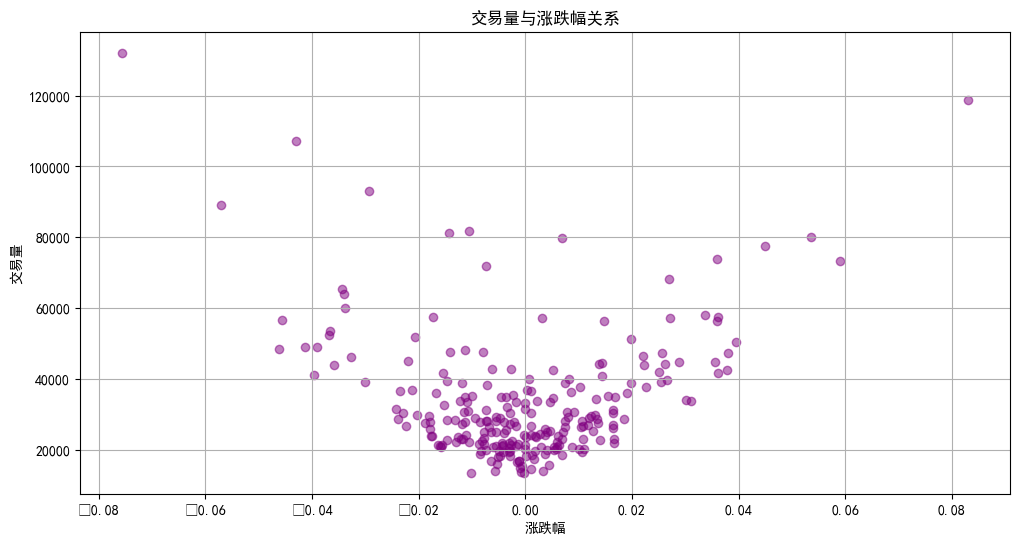

In [40]:
"""
【综合例子7】
内容：通过分析交易量、涨跌幅等数据，评估市场情绪。
例子：
计算每日涨跌幅，分析市场情绪的变化。
绘制交易量与涨跌幅的关系图。
思考一下：
1. 成交量与“涨”或者“跌”有关系吗？
2. 如何进一步分析成交量与涨跌幅之间的关系？
"""
import tushare as ts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置Tushare的token（需要注册Tushare账号获取）
ts.set_token('')
pro = ts.pro_api()

# 获取贵州茅台的历史日线数据
df = pro.daily(ts_code='600519.SH', start_date='20220101', end_date='20221231')

# 将交易日期转换为日期格式
df['trade_date'] = pd.to_datetime(df['trade_date'])

# 按日期排序
df = df.sort_values('trade_date')

# 计算每日涨跌幅
df['price_change'] = df['close'].pct_change()

# 绘制交易量与涨跌幅的关系
plt.figure(figsize=(12, 6))
plt.scatter(df['price_change'], df['vol'], alpha=0.5, color='purple')
plt.title('交易量与涨跌幅关系')
plt.xlabel('涨跌幅')
plt.ylabel('交易量')
plt.grid(True)
plt.show()


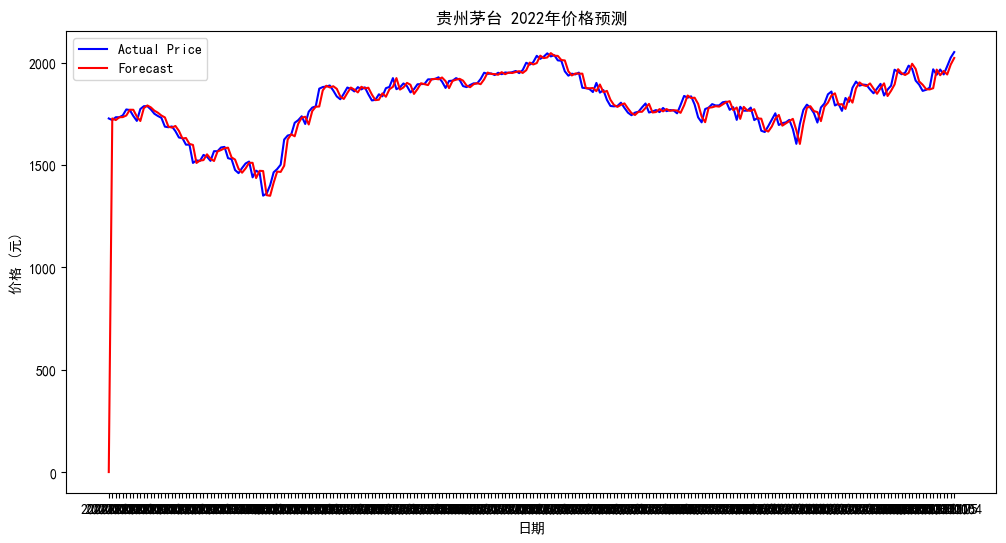

In [43]:
"""
【综合例子8】
股票数据的时间序列分析
内容：使用时间序列分析方法，预测股票价格的未来走势。
例子：
使用ARIMA模型进行价格预测。
绘制预测结果与实际价格的对比图。
思考一下：
1. x轴的坐标为什么是黑乎乎的一片？如何调整代码？
2. 为什么第一个预测值是0？如果仅仅从绘图的角度来看，怎么调整结果图才能使得结果更生动？
3. 如果用预测值做为投资的指导，回报率是多少？
"""
import tushare as ts
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA

# 设置Tushare的token（需要注册Tushare账号获取）
ts.set_token('')
pro = ts.pro_api()

# 获取贵州茅台的历史日线数据
df = pro.daily(ts_code='600519.SH', start_date='20220101', end_date='20221231')


# 使用ARIMA模型预测
model = ARIMA(df['close'], order=(5, 1, 0))
results = model.fit()
df['forecast'] = results.predict(start=0, end=len(df)-1, dynamic=False)

# 绘制预测结果
plt.figure(figsize=(12, 6))
plt.plot(df['trade_date'], df['close'], label='Actual Price', color='blue')
plt.plot(df['trade_date'], df['forecast'], label='Forecast', color='red')
plt.title('贵州茅台 2022年价格预测')
plt.xlabel('日期')
plt.ylabel('价格 (元)')
plt.legend()

plt.show()

